# Mosquitos pelo som das asas: literatura, dados reais e classificação

**Notebook de pesquisa em português.** Leitura dos três PDFs enviados, download completo do
dataset **10.5061/dryad.98d7s**, auditoria e experimentos executáveis com sinais acústicos.
Resultados publicados e resultados locais são apresentados separadamente. Os valores locais
aparecem nas saídas das células.

O percurso é: literatura → integridade → inventário → espectros/MFCC/F0 → avaliação por grupos
→ classificadores tradicionais e CNNs → TinyML de quatro classes → aparelhos não vistos
→ ruído → abstenção → INT8/C → conclusões.

**Pergunta operacional:** quanta informação sobre espécie permanece ao reservar gravações
inteiras e ao trocar aparelho ou acrescentar ruído? O notebook estima classificação exploratória;
não estima incidência de doenças.

## 1. Leitura comparada dos três trabalhos

| Trabalho | Sensor e dados | Método | Resultado publicado e contexto |
|---|---|---|---|
| [Mukundarajan et al., 2017](https://elifesciences.org/articles/27854) | Celulares, 20 espécies; referências de frequência de fêmeas | STFT, distribuições de frequência, identificação com filtro geográfico | Aproximadamente 35% → 65% em média nas espécies testadas ao incluir localização |
| [Altayeb, Zennaro e Rovai, 2022](https://doi.org/10.1145/3524458.3547258) | Subseleção do Dryad e ruídos; quatro classes | Espectrograma, CNN1D, quantização, Edge Impulse | 93,8% de acurácia geral de teste no subconjunto/protocolo próprios |
| [Fanioudakis, Geismar e Potamitis, 2018](https://doi.org/10.23919/EUSIPCO.2018.8553542) | **Sensor óptico**, Wingbeats: 279.566 eventos, seis espécies, ambos os sexos | PSD, espectrogramas e redes profundas | 96% com DenseNet121 no holdout aleatório de 20% dos eventos ópticos |

As porcentagens respondem a problemas diferentes. Wingbeats óptico não é o corpus de celulares
baixado aqui. Implementamos estratégias inspiradas nos artigos e extensões próprias; não
reproduzimos exatamente os pesos, recortes, critérios de limpeza ou percentuais dos autores.
Os PDFs originais consultados ficam apenas na cópia local; os links acima apontam às publicações.

### 1.1 Celulares: distribuição de frequência e limitações

O artigo de 2017 compara a medição acústica com vídeo de alta velocidade e entre aparelhos.
A identificação usa a distribuição de frequências durante o voo, não somente uma nota média.
Sobreposições entre espécies limitam o método; população, temperatura, sexo e coleta importam.
O resultado de 65% não é uma avaliação cega com 20 classes uniformes.

Nos métodos, a regra descrita **soma densidades por janela** para evitar que um outlier com
probabilidade zero vete uma espécie. Essa regra é diferente da log-verossimilhança convencional.
Implementamos ambas, com suavização explícita. Janelas STFT adjacentes são correlacionadas;
escores não equivalem a probabilidades calibradas de confiança.

O ganho com localização usa uma matriz de presença por país e localização escolhida em simulação.
Não reconstruímos essa matriz nem inventamos GPS, sexo ou temperatura para arquivos sem
metadados suficientes. Ver métodos nas pp. 17–19 e resultados nas pp. 9–14 do PDF.

### 1.2 TinyML: tarefa, representação e implantação

Altayeb et al. convertem áudio para 16 kHz, selecionam quatro classes e usam janelas de 1 s
com avanço de 250 ms. O espectrograma usa frames de 25 ms, avanço de 12,5 ms e 128 bandas.
A rede tem convoluções de 32/64 filtros, pooling e dropout de 50%. O treinamento usa
LR 0,001, batch 32 e early stopping; a tabela reporta 93,8% no teste.
RAM/flash/latência são avaliadas para quantização e compilação EON.

Baixamos os **ruídos reais publicados pelos autores** no
[repositório oficial](https://github.com/Mjrovai/wingbeat-mosquito-tinyml), fixado em um commit.
Cortes da mesma fonte de ruído ficam juntos. Nossa tarefa de quatro classes usa mais gravações
do acervo auditado. A CNN é compacta, com outra arquitetura/frontend e orçamento de 25 épocas.
A exportação INT8 adicional usa um modelo linear, não a rede EON. Não medimos Arduino,
TFLite Micro, LoRaWAN, bateria ou energia.

No artigo, INT8 + EON tem estimativas de **15,2 KB de RAM / 51,6 KB de flash**, com latências
de **133/27/71 ms** para Nano/Portenta/Wio. Essas medidas pertencem ao pipeline dos autores
e não são comparáveis ao payload isolado do nosso classificador linear.

### 1.3 Deep learning óptico e estratégias adicionais

Fanioudakis et al. registram passagens de insetos em gaiolas por um sensor de luz. Cada evento
tem 5.000 amostras a 8 kHz. Comparam sinal bruto, PSD de Welch e espectrogramas, com a mesma
divisão aleatória de eventos. Informação abaixo de 100 Hz inclui movimento corporal no
sensor óptico; não deve ser automaticamente atribuída ao microfone.

Também exploram clustering, Grad-CAM e transferência. Aqui priorizamos representações
acústicas, modelos pequenos e generalização. Não treinamos DenseNet no Wingbeats nem
afirmamos reproduzir a validação óptica.

Resultados da Tabela II do artigo, todos no mesmo holdout óptico:

| Modelo | Entrada | Acurácia publicada |
|---|---|---|
| DenseNet121 | Espectrograma | 96,00% |
| CNN de cinco camadas | PSD | 92,10% |
| CNN de cinco camadas | Sinal bruto | 91,20% |
| InceptionV3 | Espectrograma | 95,20% |
| MobileNet | Espectrograma | 95,62% |
| Xception | Espectrograma | 92,18% |
| NASNetMobile | Espectrograma | 94,85% |
| XGBoost | PSD | 81,81% |
| LightGBM | PSD | 82,40% |

[MosquitoSong+ (Supratak et al., 2024)](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0310121)
motiva uma extensão: adicionar ruído ao treino e testar fontes de ruído reservadas.
Adotamos mistura com SNR explícito e outra rede/acervo/duração. Esta adaptação não reproduz
os resultados publicados de MosquitoSong+.

## 2. Ambiente e configuração

O notebook contém os algoritmos e o downloader; pode ser executado na própria pasta em
Jupyter/VS Code ou Colab com armazenamento suficiente. Instale **requirements.txt**.
O sistema precisa de **libarchive**, **ffmpeg/ffprobe** e compilador C (**cc**) para a exportação.
Dados e caches ocupam vários GB. Arquivos originais ficam em **data/** e saídas em **results/**.
Seeds e hiperparâmetros são fixados; versões são registradas. GPU é opcional.
Alguns kernels ROCm/CUDA não garantem determinismo bit a bit; o manifesto registra esse limite.

In [1]:
from pathlib import Path
from collections import Counter
from datetime import datetime, timezone
import copy
import hashlib
import importlib.metadata
import json
import math
import os
import re
import subprocess
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import dct
import soundfile as sf
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
import joblib
import torch
from torch import nn
from IPython.display import display, Audio, Markdown

ROOT = Path(os.environ.get("MOSQUITO_ROOT", Path.cwd())).resolve()
sys.path.insert(0, str(ROOT))
DATA, CACHE, RESULTS = ROOT / "data", ROOT / "data/cache", ROOT / "results"
for directory in [CACHE, RESULTS, RESULTS / "models", RESULTS / "figures"]:
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = dict(seed=42, sample_rate=16000, window_s=1.0, max_windows_per_file=60,
              folds=3, mel_bands=40, fft_size=512, hop_samples=256,
              min_frequency_hz=200, max_frequency_hz=900, feature_version="1.0",
              cnn_epochs=25, cnn_patience=5, cnn_batch_size=128)
SEED, SR = CONFIG["seed"], CONFIG["sample_rate"]
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
# Deterministic algorithms are requested; unsupported GPU kernels emit warnings.
torch.use_deterministic_algorithms(True, warn_only=True)
warnings.filterwarnings("once", message=".*adaptive_avg_pool2d_backward_cuda.*")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 180, "axes.spines.top": False,
                     "axes.spines.right": False})

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def save_figure(name):
    plt.savefig(RESULTS / "figures" / f"{name}.png", bbox_inches="tight")
    plt.show()

versions = {name: importlib.metadata.version(name) for name in
            ["numpy", "scipy", "pandas", "matplotlib", "scikit-learn", "soundfile",
             "torch", "requests", "rarfile", "libarchive-c", "nbformat", "nbclient"]}
print("Dispositivo de treinamento:", DEVICE)
print("Python:", sys.version.split()[0], "| Versões:", versions)
display(pd.Series(CONFIG, name="Configuração"))

Dispositivo de treinamento: cuda
Python: 3.14.7 | Versões: {'numpy': '2.5.3', 'scipy': '1.17.1', 'pandas': '3.0.3', 'matplotlib': '3.10.9', 'scikit-learn': '1.8.0', 'soundfile': '0.14.0', 'torch': '2.12.0+rocm7.2', 'requests': '2.33.1', 'rarfile': '4.5', 'libarchive-c': '5.3', 'nbformat': '5.11.1', 'nbclient': '0.11.0'}


seed                       42
sample_rate             16000
window_s                  1.0
max_windows_per_file       60
folds                       3
mel_bands                  40
fft_size                  512
hop_samples               256
min_frequency_hz          200
max_frequency_hz          900
feature_version           1.0
cnn_epochs                 25
cnn_patience                5
cnn_batch_size            128
Name: Configuração, dtype: object

## 3. Download completo e integridade

Os metadados Dryad informam **20 RARs / 1.232.964.187 bytes** na versão auditada.
Usamos o [espelho Zenodo com o mesmo DOI](https://zenodo.org/records/4964774), pois as rotas
Dryad retornaram 401/403 neste ambiente. Antes do download, nomes, tamanhos e MD5 de ambos
os repositórios devem coincidir. Depois, cada arquivo é verificado por MD5 e recebe SHA-256 local.
As URLs efetivamente utilizadas ficam no manifesto.

RAR é extraído por libarchive; caminhos dos arquivos compactados são conferidos, downloads são
atômicos e arquivos íntegros são reutilizados. Ruídos TinyML têm commit/SHA-256 fixados.
A licença declarada do dataset Dryad/Zenodo é CC0. O código dos autores tem licença própria
e não foi incorporado ao classificador.

In [2]:
"""Download the complete Dryad dataset and verify publisher MD5 checksums."""
from __future__ import annotations

import argparse
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
import hashlib
import json
from pathlib import Path
import re
import time
import zipfile

import requests

BASE_URL = "https://datadryad.org"
DATASET_URL = BASE_URL + "/api/v2/datasets/doi%3A10.5061%2Fdryad.98d7s"
# ROOT definido na configuração.


def hashes(path: Path) -> dict:
    md5, sha256 = hashlib.md5(), hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            md5.update(block)
            sha256.update(block)
    return {"md5": md5.hexdigest(), "sha256": sha256.hexdigest()}


def get_json(url: str) -> dict:
    for attempt in range(4):
        response = requests.get(url, timeout=(20, 120))
        if response.status_code == 429 or response.status_code >= 500:
            if attempt < 3:
                delay = response.headers.get("Retry-After", "")
                time.sleep(min(int(delay), 30) if delay.isdigit() else 2 ** attempt)
                continue
        response.raise_for_status()
        return response.json()
    raise RuntimeError("Unreachable")


def metadata(data: Path) -> list[dict]:
    cache_names = ["dryad_dataset.json", "dryad_version.json", "dryad_files.json", "dryad_files_all.json"]
    if all((data / name).exists() for name in cache_names):
        dataset, version, first_page, files = [json.loads((data / name).read_text()) for name in cache_names]
        pages = [first_page]
    else:
        dataset = get_json(DATASET_URL)
        version = get_json(BASE_URL + dataset["_links"]["stash:version"]["href"])
        url = BASE_URL + version["_links"]["stash:files"]["href"]
        files, pages = [], []
        while url:
            page = get_json(url)
            pages.append(page)
            files.extend(page["_embedded"]["stash:files"])
            next_link = page["_links"].get("next")
            url = BASE_URL + next_link["href"] if next_link else None
    assert len(files) == pages[0]["total"], "Incomplete API pagination"
    # API downloads require authentication; the published landing page exposes
    # anonymous download links. Discover those links rather than inventing URLs.
    if not all("public_download_url" in info for info in files):
        landing = requests.get(BASE_URL + "/dataset/doi:10.5061/dryad.98d7s", timeout=60)
        landing.raise_for_status()
        public_links = {href.rsplit("/", 1)[-1]: BASE_URL + href
                        for href in re.findall(r'href="(/downloads/file_stream/\d+)"', landing.text)}
        for info in files:
            file_id = info["_links"]["self"]["href"].rsplit("/", 1)[-1]
            info["public_download_url"] = public_links[file_id]
    mirror_file = data / "zenodo_record.json"
    mirror = json.loads(mirror_file.read_text()) if mirror_file.exists() else get_json("https://zenodo.org/api/records/4964774")
    mirror_file.write_text(json.dumps(mirror, indent=2))
    assert mirror["metadata"]["doi"] == "10.5061/dryad.98d7s"
    mirrored = {entry["key"]: entry for entry in mirror["files"]}
    assert set(mirrored) == {entry["path"] for entry in files}
    for info in files:
        copy = mirrored[info["path"]]
        assert copy["size"] == info["size"] and copy["checksum"] == "md5:" + info["digest"]
        info["zenodo_download_url"] = copy["links"]["self"]
    for name, obj in [("dryad_dataset.json", dataset), ("dryad_version.json", version),
                      ("dryad_files.json", pages[0]), ("dryad_files_all.json", files)]:
        (data / name).write_text(json.dumps(obj, indent=2, ensure_ascii=False))
    return files


def download_file(info: dict, archive_dir: Path) -> dict:
    filename = Path(info["path"]).name
    target = archive_dir / filename
    # The Dryad API returns 401 and the public download routes return 403 in
    # this environment. Its Zenodo mirror has the same DOI and verified hashes.
    url = info["zenodo_download_url"]
    for attempt in range(4):
        try:
            if target.exists() and target.stat().st_size == info["size"]:
                digest = hashes(target)
                if digest["md5"] == info["digest"]:
                    return {"filename": filename, "size": target.stat().st_size,
                            "url": url, "official_md5": info["digest"], **digest}
            temporary = target.with_suffix(target.suffix + ".part")
            with requests.get(url, stream=True, timeout=(20, 120)) as response:
                response.raise_for_status()
                with temporary.open("wb") as stream:
                    for block in response.iter_content(1024 * 1024):
                        if block:
                            stream.write(block)
            digest = hashes(temporary)
            if temporary.stat().st_size != info["size"] or digest["md5"] != info["digest"]:
                raise ValueError(f"Size or MD5 mismatch: {filename}")
            temporary.replace(target)
            print(f"Verified: {filename} ({info['size'] / 1e6:.1f} MB)", flush=True)
            return {"filename": filename, "size": target.stat().st_size,
                    "url": url, "official_md5": info["digest"], **digest}
        except Exception as error:
            if attempt == 3:
                raise
            print(f"Retry {attempt + 1}: {filename}: {error}", flush=True)
            time.sleep(2 ** attempt)
    raise RuntimeError("Unreachable")


def extract_file(info: dict, data: Path) -> None:
    import rarfile
    import libarchive

    archive = data / "archives" / Path(info["path"]).name
    destination = data / "raw" / archive.stem
    marker = destination / ".extracted.json"
    if marker.exists():
        return
    destination.mkdir(parents=True, exist_ok=True)
    with rarfile.RarFile(archive) as handle:
        for member in handle.infolist():
            name = member.filename.replace("\\", "/")
            resolved = (destination / name).resolve()
            if not resolved.is_relative_to(destination.resolve()):
                raise ValueError(f"Unsafe archive member: {name}")
    with libarchive.file_reader(str(archive)) as entries:
        for member in entries:
            target = destination / member.pathname.replace("\\", "/")
            if not target.resolve().is_relative_to(destination.resolve()):
                raise ValueError(f"Unsafe archive member: {member.pathname}")
            if member.isdir:
                target.mkdir(parents=True, exist_ok=True)
            elif member.isfile:
                target.parent.mkdir(parents=True, exist_ok=True)
                with target.open("wb") as stream:
                    for block in member.get_blocks():
                        stream.write(block)
            else:
                raise ValueError(f"Unsupported archive entry: {member.pathname}")
    marker.write_text(json.dumps({"archive": archive.name, "md5": info["digest"]}))
    print(f"Extracted: {archive.name}", flush=True)


def fetch_dataset(root: Path = ROOT, workers: int = 3, extract: bool = True) -> list[dict]:
    data = root / "data"
    archive_dir = data / "archives"
    archive_dir.mkdir(parents=True, exist_ok=True)
    files = metadata(data)
    print(f"Dryad: {len(files)} files, {sum(f['size'] for f in files) / 1e9:.3f} GB", flush=True)
    records = []
    with ThreadPoolExecutor(max_workers=workers) as pool:
        futures = {pool.submit(download_file, info, archive_dir): info for info in files}
        for future in as_completed(futures):
            records.append(future.result())
    records.sort(key=lambda item: item["filename"])
    manifest = {"dataset_doi": "10.5061/dryad.98d7s", "retrieved_utc":
                datetime.now(timezone.utc).isoformat(), "files": records,
                "total_bytes": sum(r["size"] for r in records)}
    (data / "download_manifest.json").write_text(json.dumps(manifest, indent=2))
    if extract:
        for info in files:
            extract_file(info, data)
    return records


def fetch_noise(root: Path = ROOT) -> dict:
    """Fetch the authors' real background noises at a pinned Git commit."""
    commit = "27fdf026728c66c3a8448454987aa18b904cfce2"
    url = f"https://raw.githubusercontent.com/Mjrovai/wingbeat-mosquito-tinyml/{commit}/dataset/noise.zip"
    expected = "5f4ba031c47b4766d09d13b71a7991b8d153ba3e635c623be480128e7d3895e5"
    archive = root / "data/archives/tinyml_noise.zip"
    archive.parent.mkdir(parents=True, exist_ok=True)
    if not archive.exists() or hashes(archive)["sha256"] != expected:
        response = requests.get(url, timeout=(20, 120))
        response.raise_for_status()
        temporary = archive.with_suffix(".zip.part")
        temporary.write_bytes(response.content)
        assert hashes(temporary)["sha256"] == expected, "Noise archive checksum mismatch"
        temporary.replace(archive)
    destination = root / "data/noise"
    if not (destination / ".extracted").exists():
        destination.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(archive) as handle:
            for member in handle.infolist():
                if not (destination / member.filename).resolve().is_relative_to(destination.resolve()):
                    raise ValueError(f"Unsafe ZIP entry: {member.filename}")
            handle.extractall(destination)
        (destination / ".extracted").touch()
    result = {"source_url": url, "commit": commit, "size": archive.stat().st_size,
              "sha256": expected, "label": "noise as provided by Altayeb et al. authors"}
    (root / "data/noise_manifest.json").write_text(json.dumps(result, indent=2))
    return result



In [3]:
archives = fetch_dataset(ROOT, workers=3)
noise_provenance = fetch_noise(ROOT)
assert len(archives) == 20
assert all(record["md5"] == record["official_md5"] for record in archives)
print(f"20/20 arquivos íntegros; {sum(r['size'] for r in archives):,} bytes.")
display(pd.DataFrame(archives)[["filename", "size", "md5", "sha256"]])

Dryad: 20 files, 1.233 GB


20/20 arquivos íntegros; 1,232,964,187 bytes.


,filename,size,md5,sha256
0,Aedes aegypti.rar,38217065,f0d5a12aa87111f7aad8267d856f80c2,bf50fc2de9a56603fb6840f2e993f3a914e91fed2574a5...
1,Aedes albopictus.rar,30090736,49939d76eb5d69fcf4d460cb23d5d830,cbe01aa0a695767e415f636fadbe3b36484464dc3901d8...
2,Aedes mediovittatus.rar,1768569,46d1441939f8e30e04531ab69713d2b2,86f580431fd8fb911cabc6dac76e976e4f2ca67c905979...
3,Aedes sierrensis.rar,133048559,95fbc229d061bfd3e94289d7bf790f61,7da5df1a5e3d216ec202344c8ec13251c3d548bd774bfe...
4,Anopheles albimanus.rar,47818815,2ac9b7ddaae03d377d0b470be157e387,62b840cd814d2700218252351c5167684bc7592a146de4...
5,Anopheles arabiensis.rar,63891886,07f945f3678898f3b2e44415aa9f7b04,50d2be5a3baf5412b7eaf40446deace364806825a0d738...
6,Anopheles atroparvus.rar,28903009,8b33628ea6faf6cc36e3a82eb7734962,e213797608e31a364c2bf6e71e3126b54120f0969d94b0...
7,Anopheles dirus.rar,49678035,1cf10bf9de8e98987d146b267a7913ea,bae0370044e925a51b5de383ccd9cfdf5f7d78cd0200d9...
8,Anopheles farauti.rar,47251944,78000b1310a6ec4e461f1dac20117fd2,389d9eedfff77858dc886de3cfb9a996b83eea1e3af3b1...
9,Anopheles freeborni.rar,64978452,869632d295b451d221647b3a35a3a396,623745a3da936440ca844377196ed5fab49017a8405aed...


## 4. Inventário e rótulos

O rótulo de espécie vem da pasta, **não de anotação por segundo**. Arquivos **Background**
e ruídos identificados pelos autores recebem classe **noise**.
Inspecionamos formatos, taxas, durações e hashes.

Para Aedes sierrensis priorizamos recortes manualmente isolados; outras versões e cópias
ficam fora da avaliação. Outros recortes **Snipped** sem ligação segura com a origem são
excluídos. Formatos comprimidos são decodificados quando não há WAV correspondente.
Duplicatas exatas e conflitos de rótulo são registrados.

Aparelho e sessão são inferidos de pastas, com **unknown** quando insuficientes.
Não são IDs certificados de indivíduo/data/sessão. Podem persistir relações entre
gravações que os nomes e hashes não permitem reconstruir.

In [4]:
AUDIO_EXTENSIONS = {".wav", ".m4a", ".mp4", ".amr", ".mp3", ".flac", ".aiff", ".ogg"}

def infer_phone(path):
    text = str(path).lower()
    patterns = [("T209", r"t209"), ("Nexus", r"nexus"), ("Xperia", r"xperia"),
                ("iPhone4S", r"iphone.?4s"), ("iPhone6", r"iphone.?6"),
                ("iPhone", r"iphone"), ("Nokia5235", r"nokia.?5235"),
                ("Nokia6555B", r"nokia.?6555"), ("Huawei866C", r"huawei|866c"),
                ("HTC", r"htc")]
    return next((label for label, pattern in patterns if re.search(pattern, text)), "unknown")

def noise_source(filename):
    name = filename.lower()
    if "background" in name:
        return "background_unresolved"
    if "26nov21" in name:
        return "authors_26Nov21"
    # The final numeric suffix is the offset of a cut from the same source.
    name = re.sub(r"\.\d+\.wav$", "", name)
    name = re.sub(r"^16khz_\d+_", "", name)
    return name

def audio_info(path):
    try:
        info = sf.info(path)
        return info.samplerate, info.channels, info.frames / info.samplerate, info.subtype
    except Exception:
        result = subprocess.run(["ffprobe", "-v", "error", "-select_streams", "a:0",
                                 "-show_entries", "stream=sample_rate,channels,codec_name:format=duration",
                                 "-of", "json", str(path)], capture_output=True, text=True, check=True)
        metadata = json.loads(result.stdout)
        audio = metadata["streams"][0]
        return (int(audio["sample_rate"]), int(audio["channels"]),
                float(metadata["format"]["duration"]), audio["codec_name"])

def build_inventory():
    files = sorted((DATA / "raw").rglob("*")) + sorted((DATA / "noise").rglob("*"))
    files = [p for p in files if p.is_file() and not p.name.startswith(".")
             and "__MACOSX" not in str(p)]
    wav_sources = {(str(p.parent).replace("/Raw", ""), p.stem.lower())
                   for p in files if p.suffix.lower() == ".wav"}
    rows = []
    for path in files:
        source = "tinyml_noise" if path.is_relative_to(DATA / "noise") else "dryad"
        species = "noise" if source == "tinyml_noise" else path.relative_to(DATA / "raw").parts[0]
        explicit_noise = species == "noise" or "background" in path.name.lower()
        label = "noise" if explicit_noise else species
        reason = ""
        if path.suffix.lower() not in AUDIO_EXTENSIONS:
            reason = "non_audio"
        elif species == "Aedes sierrensis" and "CleanedData_Snipped" not in str(path):
            reason = "sierrensis_uncurated_or_copy"
        elif species != "Aedes sierrensis" and "snipped" in str(path).lower():
            reason = "derived_excerpt_unmapped"
        elif path.suffix.lower() != ".wav" and (str(path.parent).replace("/Raw", ""), path.stem.lower()) in wav_sources:
            reason = "compressed_original_has_wav"
        digest = sha256_file(path)
        rate = channels = duration = None
        subtype = ""
        if not reason:
            try:
                rate, channels, duration, subtype = audio_info(path)
                if duration < CONFIG["window_s"]:
                    reason = "shorter_than_window"
            except Exception as error:
                reason = "decode_error:" + type(error).__name__
        collector = re.match(r"([A-Za-z]+)", path.stem)
        session = (species + "|field_" + collector.group(1).lower()
                   if species == "Aedes sierrensis" and collector
                   else species + "|" + str(path.relative_to(DATA).parent))
        group = "noise|" + noise_source(path.name) if explicit_noise else digest
        rows.append(dict(path=str(path.relative_to(ROOT)), source=source, species=species,
                         label=label, phone=infer_phone(path), session=session,
                         group=group, sha256=digest, bytes=path.stat().st_size,
                         sample_rate=rate, channels=channels, duration_s=duration,
                         subtype=subtype, extension=path.suffix.lower(), exclusion=reason))
    inventory = pd.DataFrame(rows)
    valid = inventory.exclusion.eq("")
    conflicts = inventory.loc[valid].groupby("sha256").label.nunique()
    ambiguous = set(conflicts[conflicts > 1].index)
    inventory.loc[valid & inventory.sha256.isin(ambiguous), "exclusion"] = "conflicting_exact_labels"
    valid = inventory.exclusion.eq("")
    duplicates = inventory.loc[valid].duplicated("sha256", keep="first")
    inventory.loc[duplicates.index[duplicates], "exclusion"] = "exact_duplicate"
    inventory.to_csv(RESULTS / "inventory.csv", index=False)
    return inventory

def read_wave(row):
    path = ROOT / row["path"]
    try:
        wave, rate = sf.read(path, dtype="float32", always_2d=True)
        wave = wave.mean(axis=1)
        divisor = math.gcd(rate, SR)
        if rate != SR:
            wave = signal.resample_poly(wave, SR // divisor, rate // divisor).astype("float32")
    except Exception:
        decoded = CACHE / "decoded" / f"{row['sha256']}.wav"
        decoded.parent.mkdir(exist_ok=True)
        if not decoded.exists():
            subprocess.run(["ffmpeg", "-v", "error", "-nostdin", "-y", "-i", str(path),
                            "-ac", "1", "-ar", str(SR), "-c:a", "pcm_f32le", str(decoded)],
                           check=True, capture_output=True)
        wave, _ = sf.read(decoded, dtype="float32")
    return np.nan_to_num(wave).astype("float32")

exclusion
included                        820
sierrensis_uncurated_or_copy    326
compressed_original_has_wav     203
exact_duplicate                  64
non_audio                        63
shorter_than_window              50
derived_excerpt_unmapped          9
conflicting_exact_labels          2
Name: Arquivos, dtype: int64

,recordings,groups,minutes
label,,,
Aedes aegypti,20,20,28.542059
Aedes albopictus,7,7,16.106104
Aedes mediovittatus,3,3,3.000000
Aedes sierrensis,60,60,4.254113
Anopheles albimanus,40,40,39.793738
Anopheles arabiensis,13,13,33.064580
Anopheles atroparvus,7,7,15.127383
Anopheles dirus,56,56,42.703707
Anopheles farauti,46,46,36.656400


Taxas declaradas nos arquivos: [np.float64(8000.0), np.float64(16000.0), np.float64(44100.0), np.float64(48000.0)]
Formatos inventariados: {'.wav': 1143, '.m4a': 168, '.amr': 123, '.mat': 55, '.mp4': 40, '.png': 7, '.gpx': 1}


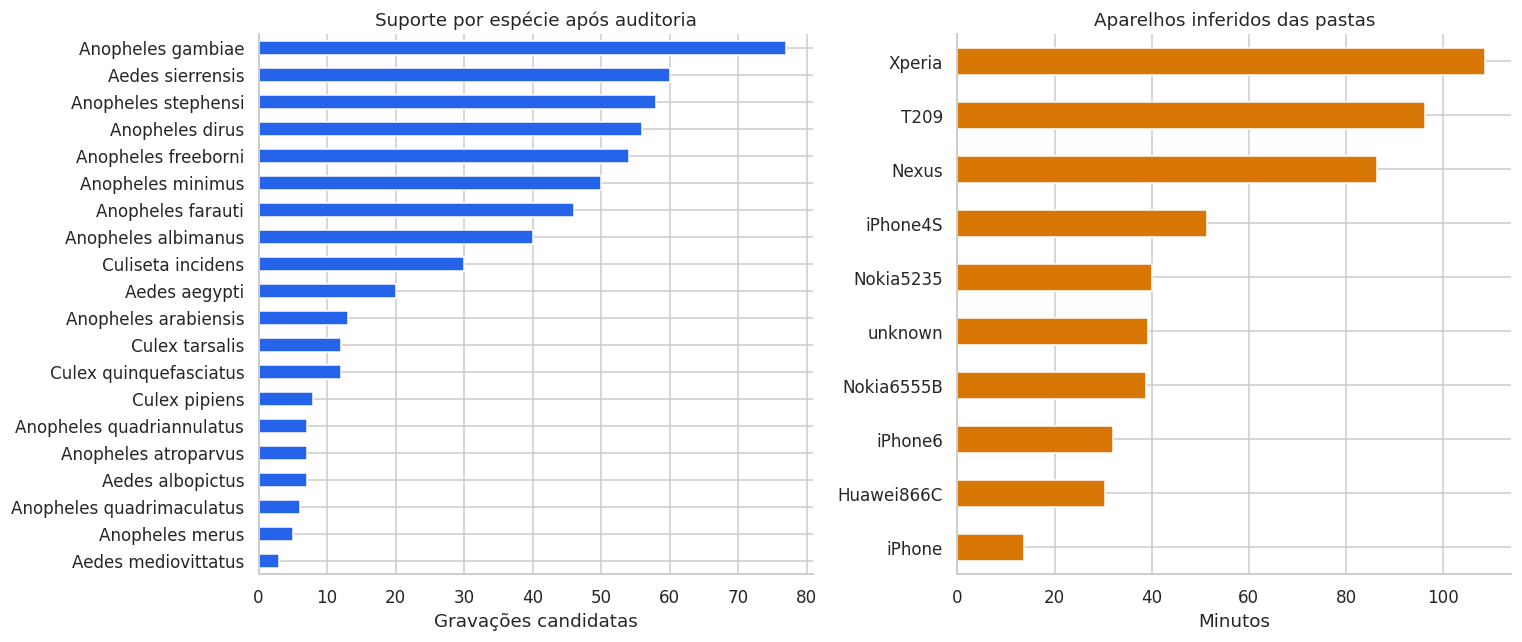

In [5]:
inventory = build_inventory()
usable = inventory.loc[inventory.exclusion.eq("")].copy()
display(inventory.exclusion.replace("", "included").value_counts().rename("Arquivos"))
display(usable.groupby("label").agg(recordings=("path", "size"), groups=("group", "nunique"),
                                    minutes=("duration_s", lambda x: x.sum() / 60)))
print("Taxas declaradas nos arquivos:", sorted(usable.sample_rate.dropna().unique()))
print("Formatos inventariados:", inventory.extension.value_counts().to_dict())
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
counts = usable[usable.label != "noise"].groupby("label").size().sort_values()
counts.plot.barh(ax=axes[0], color="#2563eb")
axes[0].set(xlabel="Gravações candidatas", ylabel="", title="Suporte por espécie após auditoria")
usable.groupby("phone").duration_s.sum().div(60).sort_values().plot.barh(ax=axes[1], color="#d97706")
axes[1].set(xlabel="Minutos", ylabel="", title="Aparelhos inferidos das pastas")
plt.tight_layout()
save_figure("inventory")

## 5. Sinais, F0, PSD e MFCC

Reamostramos com anti-alias para 16 kHz e combinamos canais por média. O frontend Mel usa
100–3900 Hz, compatível com a faixa de arquivos originalmente a 8 kHz.
Reamostrar de 8 para 16 kHz não acrescenta informação acima do Nyquist original.

Janelas de **1 s sem sobreposição**, no máximo 60 por arquivo, distribuídas ao longo da gravação.
Arquivos curtos e janelas praticamente nulas são excluídos. O download inclui todo o dataset;
este limite diz respeito à amostra computacional.

Cada janela gera 13 médias/13 desvios de MFCC, PSD em frequências fixas e descritores
de frequência/harmônicos. Para F0, usamos STFT de 200 ms, passo de 20 ms e bins de 5 Hz.
A busca em 200–900 Hz amplia a faixa do foco original em fêmeas. É uma estimativa por pico;
pode selecionar ruído/harmônicos. Não selecionamos sexo a partir de metadados curados.
As CNNs usam 40 bandas Mel, FFT de 512 e avanço de 256 (32/16 ms).

Também verificamos formas de onda idênticas após reamostragem. Arquivos conectados recebem
o mesmo grupo; trechos repetidos/conflitantes não são contados duas vezes. Isso reduz
vazamento verificável, sem provar independência entre indivíduos/colônias.

In [6]:
def mel_filterbank():
    frequencies = np.fft.rfftfreq(CONFIG["fft_size"], 1 / SR)
    to_mel = lambda f: 2595 * np.log10(1 + f / 700)
    to_hz = lambda m: 700 * (10 ** (m / 2595) - 1)
    limits = to_hz(np.linspace(to_mel(100), to_mel(3900), CONFIG["mel_bands"] + 2))
    bank = np.zeros((CONFIG["mel_bands"], len(frequencies)), dtype="float32")
    for k in range(len(bank)):
        bank[k] = np.maximum(0, np.minimum((frequencies - limits[k]) / (limits[k+1] - limits[k]),
                                          (limits[k+2] - frequencies) / (limits[k+2] - limits[k+1])))
        bank[k] /= max(bank[k].sum(), 1e-12)
    return bank

MEL_BANK = mel_filterbank()
PSD_BINS = np.arange(150, 3951, 50)
F0_BINS = np.arange(200, 905, 5)
FEATURE_NAMES = ([f"mfcc_mean_{i}" for i in range(13)] + [f"mfcc_std_{i}" for i in range(13)] +
                 [f"psd_{int(f)}Hz" for f in PSD_BINS] +
                 ["f0_median", "f0_std", "f0_q10", "f0_q90", "peak_frequency",
                  "harmonic_f0", "spectral_centroid", "spectral_flatness", "spectral_entropy"])

def wave_features(raw_wave):
    wave = np.asarray(raw_wave, dtype="float32")
    wave = wave - wave.mean()
    rms = float(np.sqrt(np.mean(wave**2)))
    wave = wave / max(rms, 1e-8)
    freqs, _, spectrum = signal.stft(wave, fs=SR, nperseg=CONFIG["fft_size"],
                                     noverlap=CONFIG["fft_size"] - CONFIG["hop_samples"],
                                     boundary=None, padded=False)
    mel = MEL_BANK @ np.abs(spectrum)**2
    mel_db = 10 * np.log10(np.maximum(mel, 1e-12))
    mel_db = np.clip(mel_db - mel_db.max(), -80, 0)
    mfcc = dct(mel_db, type=2, axis=0, norm="ortho")[:13]
    f, psd = signal.welch(wave, fs=SR, nperseg=3200, noverlap=2880)
    selected = (f >= 150) & (f <= 3900)
    probabilities = psd[selected] / max(psd[selected].sum(), 1e-12)
    log_psd = 10 * np.log10(np.maximum(np.interp(PSD_BINS, f, psd), 1e-12))
    log_psd -= log_psd.max()
    # Long windows: nominal 5-Hz bins and 20-ms step, matching the 2017 design.
    ff, _, long_stft = signal.stft(wave, fs=SR, nperseg=3200, noverlap=2880,
                                   boundary=None, padded=False)
    band = (ff >= 200) & (ff <= 900)
    track = ff[band][np.abs(long_stft[band]).argmax(axis=0)]
    hist = np.histogram(track, bins=F0_BINS)[0].astype("float32")
    hist /= max(hist.sum(), 1)
    candidates = np.arange(200, 901, 5)
    harmonic_scores = sum(np.interp(candidates * harmonic, f, psd) / harmonic
                          for harmonic in [1, 2, 3])
    peak_frequency = f[(f >= 200) & (f <= 900)][psd[(f >= 200) & (f <= 900)].argmax()]
    summary = [np.median(track), np.std(track), *np.quantile(track, [.1, .9]),
               peak_frequency, candidates[harmonic_scores.argmax()],
               np.sum(f[selected] * probabilities),
               np.exp(np.mean(np.log(np.maximum(probabilities, 1e-12)))) / max(probabilities.mean(), 1e-12),
               -np.sum(probabilities * np.log(np.maximum(probabilities, 1e-12)))]
    features = np.r_[mfcc.mean(axis=1), mfcc.std(axis=1), log_psd, summary].astype("float32")
    return features, hist, (mel_db / 80).astype("float32"), rms

def prepare_features(usable):
    fingerprint = hashlib.sha256((usable[["path", "sha256", "group", "label"]].to_json() +
                                   json.dumps(CONFIG, sort_keys=True)).encode()).hexdigest()
    marker = CACHE / "features_manifest.json"
    if marker.exists() and json.loads(marker.read_text())["fingerprint"] == fingerprint:
        arrays = np.load(CACHE / "features.npz")
        return (pd.read_csv(CACHE / "segments.csv"), arrays["features"], arrays["histograms"],
                np.load(CACHE / "waves.npy", mmap_mode="r"), np.load(CACHE / "mel.npy", mmap_mode="r"))
    segments, features, histograms, waves, spectrograms = [], [], [], [], []
    for number, (_, row) in enumerate(usable.iterrows(), 1):
        wave = read_wave(row)
        n_windows = len(wave) // SR
        positions = np.unique(np.linspace(0, n_windows - 1, min(n_windows, CONFIG["max_windows_per_file"])).astype(int))
        for position in positions:
            window = wave[position * SR:(position + 1) * SR]
            if len(window) != SR or np.sqrt(np.mean(window**2)) < 1e-7:
                continue
            feature, histogram, mel, rms = wave_features(window)
            normalized = window - window.mean()
            normalized /= max(np.sqrt(np.mean(normalized**2)), 1e-8)
            content = hashlib.sha256(np.round(window * 32767).astype("int32").tobytes()).hexdigest()
            segments.append(dict(path=row.path, label=row.label, group=row.group, phone=row.phone,
                                 session=row.session, start_s=int(position), duration_s=1,
                                 rms=rms, content_sha256=content))
            features.append(feature); histograms.append(histogram)
            waves.append(normalized.astype("float32")); spectrograms.append(mel)
        if number % 50 == 0 or number == len(usable):
            print(f"Features: {number}/{len(usable)} gravações, {len(segments)} janelas", flush=True)
    segments = pd.DataFrame(segments)
    # Connect groups sharing an identical waveform; remove duplicated windows.
    parent = {group: group for group in segments.group.unique()}
    def find(group):
        while parent[group] != group:
            parent[group] = parent[parent[group]]
            group = parent[group]
        return group
    conflicted = set()
    for digest, subset in segments.groupby("content_sha256"):
        groups = subset.group.unique()
        if len(groups) > 1:
            if subset.label.nunique() > 1:
                conflicted.add(digest)
            else:
                for group in groups[1:]:
                    parent[find(group)] = find(groups[0])
    segments["group"] = segments.group.map(find)
    keep = (~segments.content_sha256.isin(conflicted) &
            ~segments.duplicated("content_sha256", keep="first")).to_numpy()
    duplicate_audit = dict(conflicting_waveforms=len(conflicted),
                           dropped_windows=int((~keep).sum()), retained_windows=int(keep.sum()))
    segments = segments.loc[keep].reset_index(drop=True)
    arrays = [np.stack(items)[keep] for items in [features, histograms, waves, spectrograms]]
    np.savez_compressed(CACHE / "features.npz", features=arrays[0], histograms=arrays[1])
    np.save(CACHE / "waves.npy", arrays[2]); np.save(CACHE / "mel.npy", arrays[3])
    segments.to_csv(CACHE / "segments.csv", index=False)
    marker.write_text(json.dumps(dict(fingerprint=fingerprint, config=CONFIG,
                                     segment_audit=duplicate_audit), indent=2))
    return segments, arrays[0], arrays[1], arrays[2], arrays[3]

,windows,groups
label,,
Aedes aegypti,1200,20
Aedes albopictus,420,7
Aedes mediovittatus,180,3
Aedes sierrensis,227,60
Anopheles albimanus,2131,40
Anopheles arabiensis,780,13
Anopheles atroparvus,420,7
Anopheles dirus,2414,55
Anopheles farauti,2087,46


{'conflicting_waveforms': 1, 'dropped_windows': 67, 'retained_windows': 24405}

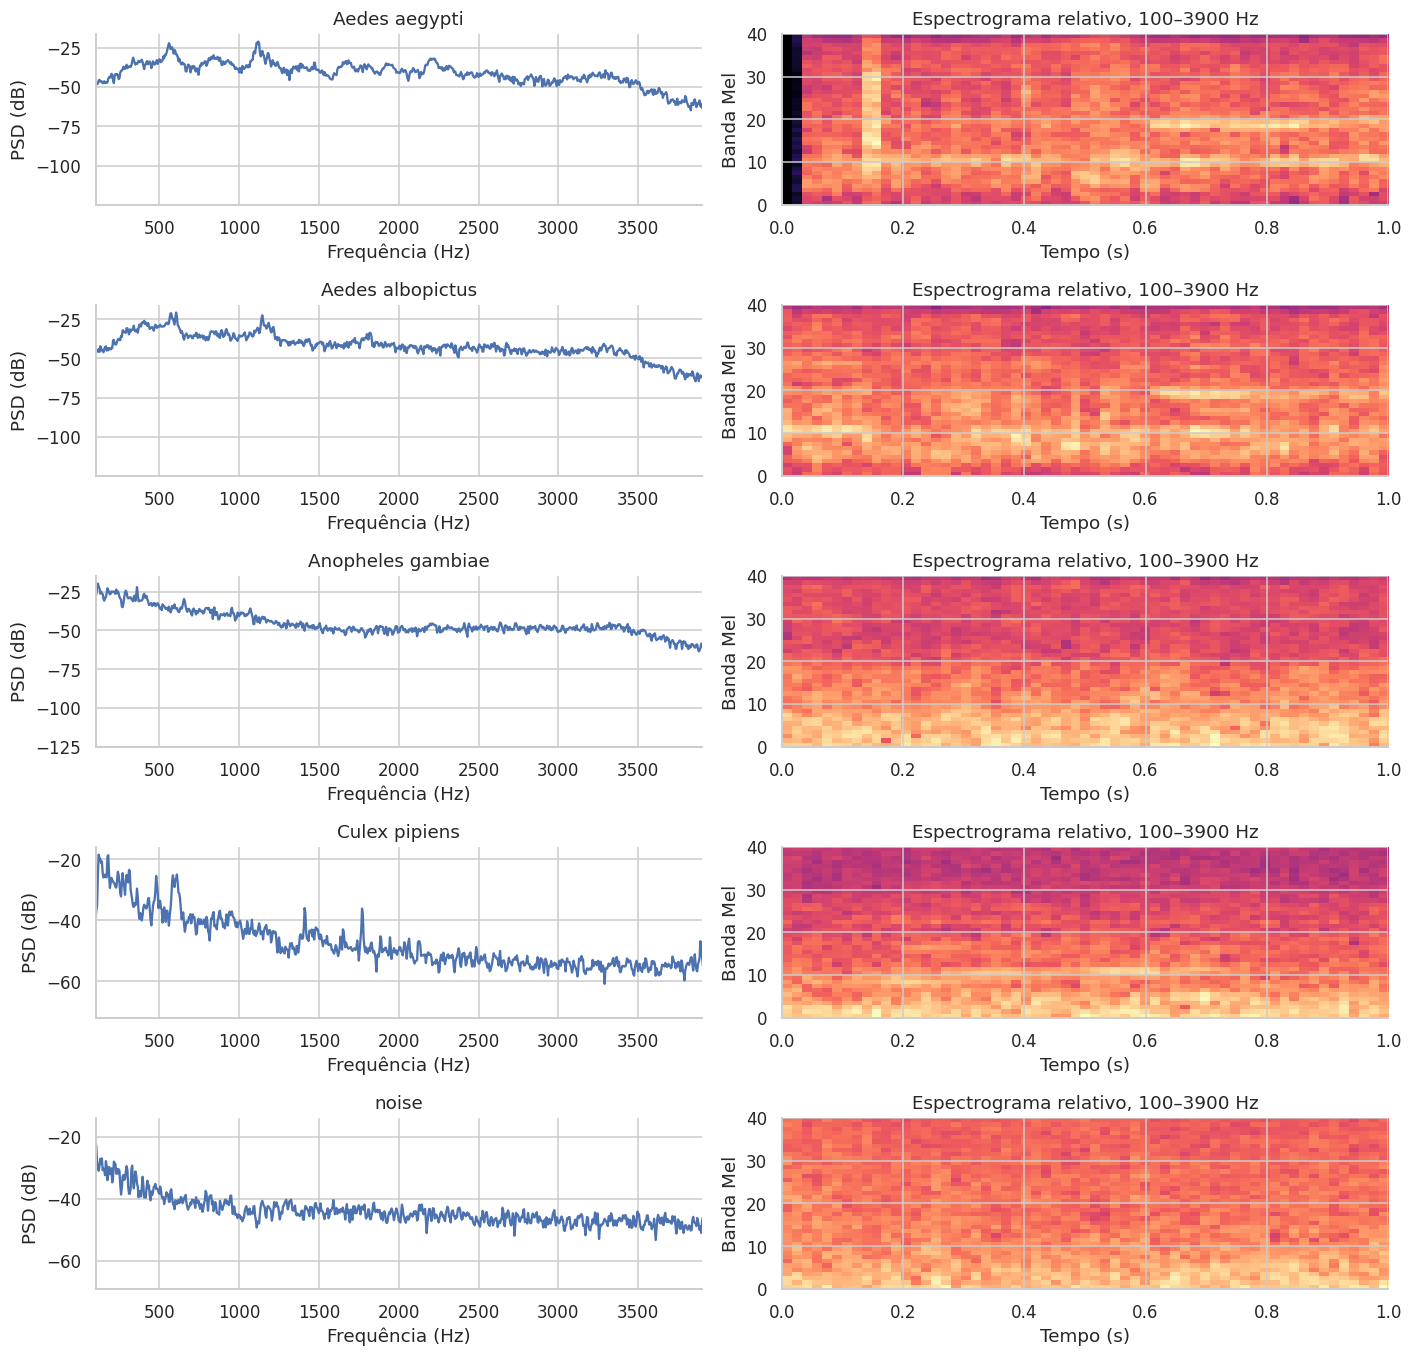

Aedes aegypti | data/raw/Aedes aegypti/Aedes aegypti/CDC_T209/Voice0135 AEGY10130f.wav | início: 0


Aedes albopictus | data/raw/Aedes albopictus/Aedes albopictus/CDC_T209/Voice0138.wav | início: 30


noise | data/noise/noise/16khz_3_noise.26Nov21.wav | início: 40


In [7]:
segments, X, H, WAVES, MEL = prepare_features(usable)
assert X.shape[1] == len(FEATURE_NAMES)
assert len(segments) == len(X) == len(H) == len(WAVES) == len(MEL)
assert np.isfinite(X).all() and np.isfinite(H).all()
segments.to_csv(RESULTS / "segments.csv", index=False)
support = segments.groupby("label").agg(windows=("label", "size"), groups=("group", "nunique"))
display(support)
display(json.loads((CACHE / "features_manifest.json").read_text())["segment_audit"])
examples = {}
for label in ["Aedes aegypti", "Aedes albopictus", "Anopheles gambiae", "Culex pipiens", "noise"]:
    candidates = segments.index[segments.label.eq(label)]
    if len(candidates):
        # An example is selected for illustration; it is not an activity annotation.
        examples[label] = candidates[len(candidates) // 2]
fig, axes = plt.subplots(len(examples), 2, figsize=(13, 2.5 * len(examples)), squeeze=False)
for (label, idx), pair in zip(examples.items(), axes):
    f, psd = signal.welch(WAVES[idx], SR, nperseg=3200)
    pair[0].plot(f, 10 * np.log10(np.maximum(psd, 1e-12)))
    pair[0].set(xlim=(100, 3900), xlabel="Frequência (Hz)", ylabel="PSD (dB)", title=label)
    pair[1].imshow(MEL[idx], aspect="auto", origin="lower", extent=[0, 1, 0, 40], cmap="magma", vmin=-1, vmax=0)
    pair[1].set(xlabel="Tempo (s)", ylabel="Banda Mel", title="Espectrograma relativo, 100–3900 Hz")
plt.tight_layout()
save_figure("signal_examples")
for label in ["Aedes aegypti", "Aedes albopictus", "noise"]:
    if label in examples:
        idx = examples[label]
        print(label, "|", segments.iloc[idx]["path"], "| início:", segments.iloc[idx].start_s)
        display(Audio(np.asarray(WAVES[idx]), rate=SR))

## 6. Avaliação por gravação/fonte

Distribuímos grupos inteiros em três dobras estratificadas **no nível do grupo**, depois
alocamos as janelas. Gravações e trechos relacionados ficam juntos. Asserções verificam
grupos e formas de onda idênticas entre treino e teste.
Espécies com menos de três grupos seriam excluídas e reportadas.

Padronização e modelos são ajustados no treino. CNNs usam validação interna por grupos
para early stopping; teste externo fica reservado. Pesos/amostragem equilibram classes
e grupos, evitando domínio de arquivos longos.

Reportamos accuracy, balanced accuracy/macro recall e macro-F1 por janela.
Por grupo, agregamos escores e calculamos macro recall. Bootstrap reamostra grupos
dentro de cada espécie. Os intervalos são descritivos e condicionais a este acervo/modelo:
não incorporam toda a dependência por colônia ou incerteza populacional.
Comparar oito modelos nas mesmas dobras é exploratório; não há teste final independente.

In [8]:
def assign_folds(labels, groups):
    group_table = pd.DataFrame({"group": groups, "label": labels})
    assert group_table.groupby("group").label.nunique().max() == 1
    table = group_table.drop_duplicates("group").reset_index(drop=True)
    support = table.label.value_counts()
    included = table[table.label.isin(support[support >= CONFIG["folds"]].index)].copy()
    splitter = StratifiedKFold(n_splits=CONFIG["folds"], shuffle=True, random_state=SEED)
    assignments = {}
    for fold, (_, test) in enumerate(splitter.split(included, included.label)):
        assignments.update({group: fold for group in included.iloc[test].group})
    return np.array([assignments.get(group, -1) for group in groups]), support

def nested_holdout(indices, labels):
    rng = np.random.default_rng(SEED + len(indices))
    table = pd.DataFrame({"group": segments.iloc[indices].group.to_numpy(),
                          "label": labels[indices]}).drop_duplicates("group")
    validation_groups = []
    for label, subset in table.groupby("label"):
        groups = subset.group.to_numpy().copy()
        if len(groups) < 2:
            raise ValueError(f"Faltam grupos para treino/validação: {label}")
        rng.shuffle(groups)
        validation_groups.extend(groups[:max(1, int(np.ceil(len(groups) * .2)))])
    is_validation = segments.iloc[indices].group.isin(validation_groups).to_numpy()
    train, validation = indices[~is_validation], indices[is_validation]
    assert set(segments.iloc[train].group).isdisjoint(segments.iloc[validation].group)
    return train, validation

def group_weights(indices, labels):
    frame = pd.DataFrame({"group": segments.iloc[indices].group.to_numpy(),
                          "label": labels[indices]})
    group_sizes = frame.groupby("group").size()
    class_groups = frame.drop_duplicates("group").groupby("label").size()
    weights = 1 / (frame.group.map(group_sizes).to_numpy() * frame.label.map(class_groups).to_numpy())
    return weights / weights.mean()

def as_probabilities(model, features):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)
    scores = model.decision_function(features)
    if scores.ndim == 1:
        scores = np.c_[-scores, scores]
    scores = scores - scores.max(axis=1, keepdims=True)
    return np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)

def metrics(y_true, predicted):
    return dict(accuracy=accuracy_score(y_true, predicted),
                balanced_accuracy=balanced_accuracy_score(y_true, predicted),
                macro_f1=f1_score(y_true, predicted, average="macro", zero_division=0))

def aggregate_recordings(indices, y_true, probabilities, class_names):
    frame = segments.iloc[indices][["path", "group", "phone", "session"]].copy()
    frame["true"] = y_true
    probability_columns = [f"p{i}" for i in range(len(class_names))]
    frame[probability_columns] = probabilities
    result = frame.groupby("group").agg(path=("path", "first"), phone=("phone", "first"),
                                       session=("session", "first"), true=("true", "first"),
                                       windows=("true", "size"))
    scores = frame.groupby("group")[probability_columns].mean().to_numpy()
    result["predicted"] = scores.argmax(axis=1)
    result["true_label"] = np.asarray(class_names)[result.true.to_numpy().astype(int)]
    result["predicted_label"] = np.asarray(class_names)[result.predicted.to_numpy().astype(int)]
    result["max_score"] = scores.max(axis=1)
    return result.reset_index()

def bootstrap_macro_recall(recordings, repeats=1000):
    rng = np.random.default_rng(SEED)
    # Resample recording/source groups within each species, not audio windows.
    classes = [(row.true == row.predicted).to_numpy() for _, row in recordings.groupby("true")]
    values = []
    for _ in range(repeats):
        recalls = []
        for correct in classes:
            recalls.append(correct[rng.integers(0, len(correct), len(correct))].mean())
        values.append(np.mean(recalls))
    return np.quantile(values, [.025, .975])

class FrequencyDistributionClassifier:
    """Additive density score (2017 description) or smoothed log likelihood."""
    def __init__(self, logarithmic=False):
        self.logarithmic = logarithmic

    def fit(self, histograms, labels, sample_weight=None):
        self.classes_ = np.unique(labels)
        weights = np.ones(len(labels)) if sample_weight is None else sample_weight
        self.references_ = np.stack([np.average(histograms[labels == label], axis=0,
                                               weights=weights[labels == label])
                                     for label in self.classes_])
        # Fixed Dirichlet-style smoothing: finite logs for unseen frequency bins.
        self.references_ = self.references_ + 1e-4
        self.references_ /= self.references_.sum(axis=1, keepdims=True)
        return self

    def predict_proba(self, histograms):
        references = np.log(self.references_) if self.logarithmic else self.references_
        scores = histograms @ references.T
        scores -= scores.max(axis=1, keepdims=True)
        return np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)

In [9]:
fold_ids, group_support = assign_folds(segments.label.to_numpy(), segments.group.to_numpy())
segments["fold_species"] = fold_ids
species_encoder = LabelEncoder().fit(segments.loc[(fold_ids >= 0) & segments.label.ne("noise"), "label"])
SPECIES = species_encoder.classes_
Y_SPECIES = np.full(len(segments), -1, dtype=int)
species_mask = segments.label.isin(SPECIES).to_numpy()
Y_SPECIES[species_mask] = species_encoder.transform(segments.loc[species_mask, "label"])
PRIMARY = np.flatnonzero((fold_ids >= 0) & (Y_SPECIES >= 0))
TINY_NAMES = np.array(["aegypti", "albopictus", "noise", "other"])
tiny_labels = segments.label.map(lambda label: {"Aedes aegypti": "aegypti", "Aedes albopictus": "albopictus",
                                               "noise": "noise"}.get(label, "other")).to_numpy()
Y_TINY = np.searchsorted(TINY_NAMES, tiny_labels)
tiny_folds, _ = assign_folds(tiny_labels, segments.group.to_numpy())
segments["fold_tinyml"] = tiny_folds
segments.to_csv(RESULTS / "segments.csv", index=False)
for assignments in [fold_ids, tiny_folds]:
    assert pd.DataFrame({"group": segments.group, "fold": assignments}).groupby("group").fold.nunique().max() == 1
for fold in range(CONFIG["folds"]):
    train = PRIMARY[fold_ids[PRIMARY] != fold]
    test = PRIMARY[fold_ids[PRIMARY] == fold]
    assert set(segments.iloc[train].group).isdisjoint(segments.iloc[test].group)
    assert set(segments.iloc[train].content_sha256).isdisjoint(segments.iloc[test].content_sha256)
    assert len(np.unique(Y_SPECIES[train])) == len(SPECIES)
    assert len(np.unique(Y_SPECIES[test])) == len(SPECIES)
display(pd.crosstab(segments.loc[PRIMARY, "label"], fold_ids[PRIMARY]))
print("Espécies efetivamente avaliadas:", len(SPECIES))
print("Espécies sem grupos suficientes:", group_support[group_support < CONFIG["folds"]].to_dict())
print("Janelas no benchmark:", len(PRIMARY), "| grupos:", segments.iloc[PRIMARY].group.nunique())

col_0,0,1,2
label,,,
Aedes aegypti,420,420,360
Aedes albopictus,120,120,180
Aedes mediovittatus,60,60,60
Aedes sierrensis,90,61,76
Anopheles albimanus,691,702,738
Anopheles arabiensis,300,240,240
Anopheles atroparvus,120,180,120
Anopheles dirus,757,881,776
Anopheles farauti,718,644,725


Espécies efetivamente avaliadas: 20
Espécies sem grupos suficientes: {}
Janelas no benchmark: 23877 | grupos: 569


## 7. Métodos tradicionais

Comparamos classe majoritária, distribuição de F0 com soma de densidades/log-verossimilhança,
PSD + SVM linear, MFCC + regressão logística e ExtraTrees com todos os descritores.
Referências de frequência são construídas apenas no treino.

Escore aditivo: $s_k = \sum_b h_b p_{kb}$. Variante logarítmica:
$s_k = \sum_b h_b \log(p_{kb}+\epsilon)$.
Softmax de escores/margens facilita agregação, mas não demonstra calibração.
Nomes de espécies/pastas não são features acústicas.

In [10]:
MFCC_COLUMNS = np.arange(26)
PSD_COLUMNS = np.arange(26, 26 + len(PSD_BINS))
MODEL_SPECS = {
    "Majoritária": (DummyClassifier(strategy="most_frequent"), X, np.arange(X.shape[1])),
    "F0: soma de densidades": (FrequencyDistributionClassifier(False), H, None),
    "F0: log-verossimilhança": (FrequencyDistributionClassifier(True), H, None),
    "PSD + SVM linear": (make_pipeline(StandardScaler(), LinearSVC(C=1, max_iter=6000, random_state=SEED)),
                         X[:, PSD_COLUMNS], PSD_COLUMNS),
    "MFCC + regressão logística": (make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=3000, random_state=SEED)),
                                    X[:, MFCC_COLUMNS], MFCC_COLUMNS),
    "MFCC/PSD/F0 + ExtraTrees": (ExtraTreesClassifier(n_estimators=200, min_samples_leaf=2,
                                                     max_features="sqrt", n_jobs=4, random_state=SEED),
                                 X, np.arange(X.shape[1])),
}
CLASSICAL_MODELS, OOF, RECORDINGS, summary_rows = {}, {}, {}, []
for name, (prototype, features, columns) in MODEL_SPECS.items():
    probabilities = np.zeros((len(PRIMARY), len(SPECIES)), dtype="float32")
    trained = []
    elapsed = 0
    for fold in range(CONFIG["folds"]):
        train = PRIMARY[fold_ids[PRIMARY] != fold]
        locations = np.flatnonzero(fold_ids[PRIMARY] == fold)
        test = PRIMARY[locations]
        model = copy.deepcopy(prototype)
        weights = group_weights(train, Y_SPECIES)
        begin = time.perf_counter()
        if isinstance(model, FrequencyDistributionClassifier):
            model.fit(features[train], Y_SPECIES[train], sample_weight=weights)
        elif isinstance(model, DummyClassifier):
            model.fit(features[train], Y_SPECIES[train])
        elif hasattr(model, "steps"):
            model.fit(features[train], Y_SPECIES[train],
                      **{model.steps[-1][0] + "__sample_weight": weights})
        else:
            model.fit(features[train], Y_SPECIES[train], sample_weight=weights)
        elapsed += time.perf_counter() - begin
        probabilities[locations] = as_probabilities(model, features[test])
        trained.append(model)
    CLASSICAL_MODELS[name] = trained
    OOF[name] = probabilities
    recording_predictions = aggregate_recordings(PRIMARY, Y_SPECIES[PRIMARY], probabilities, SPECIES)
    RECORDINGS[name] = recording_predictions
    low, high = bootstrap_macro_recall(recording_predictions)
    row = dict(model=name, task="species", n_classes=len(SPECIES), n_windows=len(PRIMARY),
               n_groups=len(recording_predictions), **metrics(Y_SPECIES[PRIMARY], probabilities.argmax(axis=1)),
               recording_macro_recall=balanced_accuracy_score(recording_predictions.true, recording_predictions.predicted),
               ci_low=low, ci_high=high, training_seconds=elapsed)
    summary_rows.append(row)
    print(name, "| acurácia balanceada por grupo:", round(row["recording_macro_recall"], 3), flush=True)
    recording_predictions.to_csv(RESULTS / f"predictions_classical_{len(summary_rows)}.csv", index=False)
joblib.dump(dict(models=CLASSICAL_MODELS, classes=SPECIES, config=CONFIG),
            RESULTS / "models/classical_folds.joblib", compress=3)
classical_summary = pd.DataFrame(summary_rows)
classical_summary.to_csv(RESULTS / "classical_metrics.csv", index=False)
display(classical_summary.round(4))

Majoritária | acurácia balanceada por grupo: 0.05


F0: soma de densidades | acurácia balanceada por grupo: 0.429


F0: log-verossimilhança | acurácia balanceada por grupo: 0.659


PSD + SVM linear | acurácia balanceada por grupo: 0.608


MFCC + regressão logística | acurácia balanceada por grupo: 0.64


MFCC/PSD/F0 + ExtraTrees | acurácia balanceada por grupo: 0.683


,model,task,n_classes,n_windows,n_groups,accuracy,balanced_accuracy,macro_f1,recording_macro_recall,ci_low,ci_high,training_seconds
0,Majoritária,species,20,23877,569,0.1096,0.0492,0.0175,0.0503,0.0412,0.0590,0.0040
1,F0: soma de densidades,species,20,23877,569,0.2030,0.3271,0.1992,0.4285,0.3926,0.4615,0.0167
2,F0: log-verossimilhança,species,20,23877,569,0.2979,0.4181,0.3064,0.6590,0.6201,0.6956,0.0146
3,PSD + SVM linear,species,20,23877,569,0.2746,0.4149,0.2779,0.6081,0.5736,0.6420,4.0560
4,MFCC + regressão logística,species,20,23877,569,0.3396,0.4794,0.3810,0.6396,0.6015,0.6798,1.4259
5,MFCC/PSD/F0 + ExtraTrees,species,20,23877,569,0.4125,0.4892,0.4561,0.6826,0.6350,0.7242,3.4240


### Sobreposição e erros

Bhattacharyya usa todas as gravações para **visualização descritiva**. Não entra no treino
ou na seleção de parâmetros. A confusão usa previsões fora da dobra.
Sobreposição de F0 não determina, sozinha, o resultado de modelos que usam harmônicos
e dinâmica espectral.

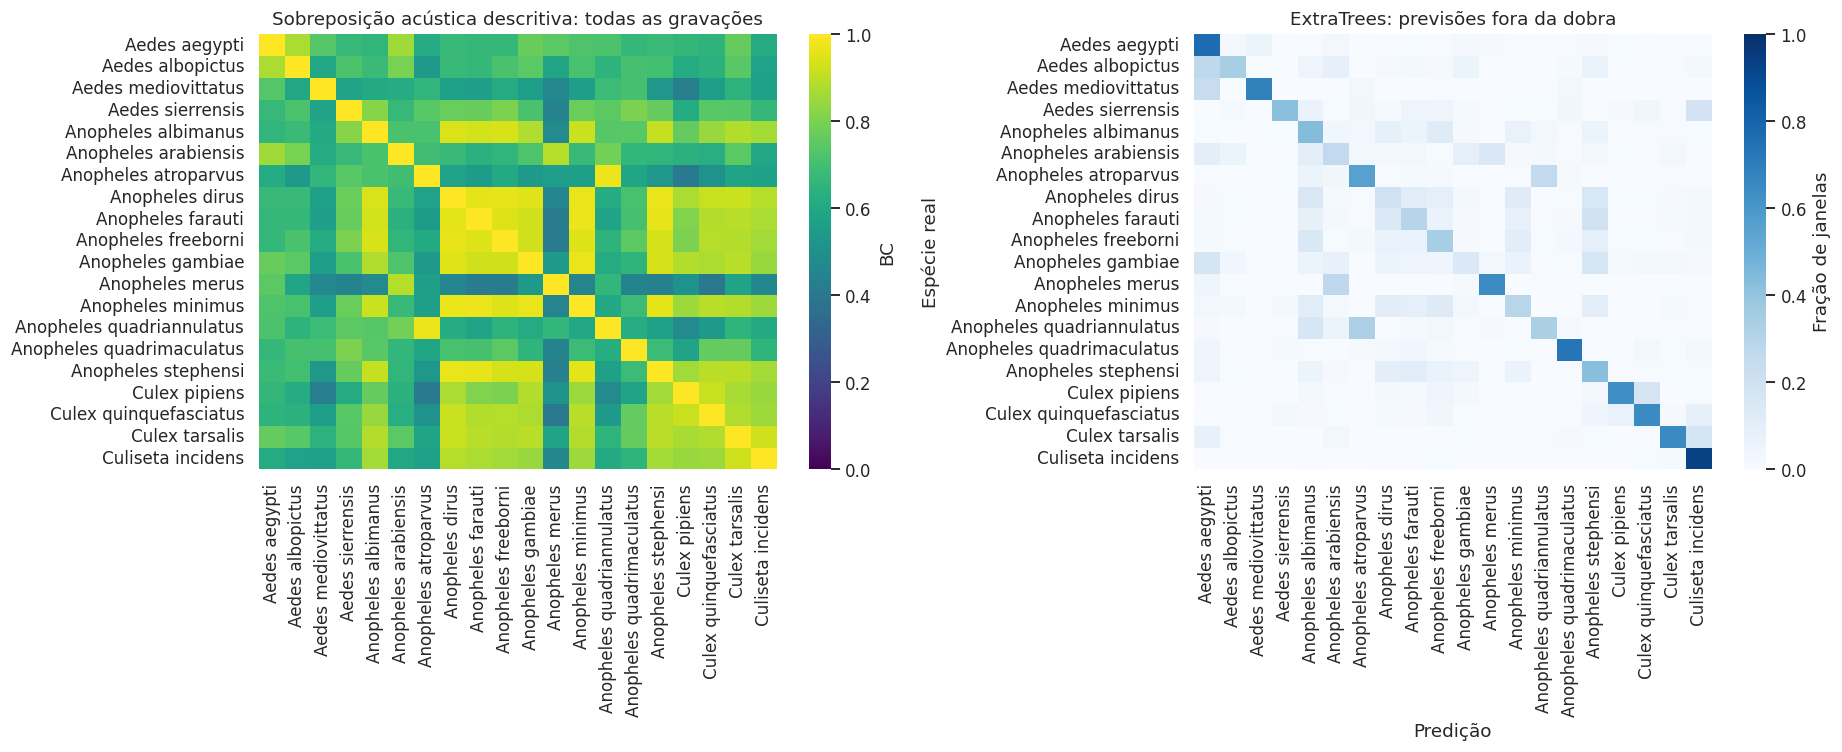

In [11]:
reference_histograms = []
for label in SPECIES:
    indices = np.flatnonzero(segments.label.eq(label).to_numpy())
    weights = group_weights(indices, Y_SPECIES)
    histogram = np.average(H[indices], axis=0, weights=weights) + 1e-6
    reference_histograms.append(histogram / histogram.sum())
reference_histograms = np.stack(reference_histograms)
bhattacharyya = np.sqrt(reference_histograms) @ np.sqrt(reference_histograms).T
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.heatmap(bhattacharyya, vmin=0, vmax=1, cmap="viridis", xticklabels=SPECIES,
            yticklabels=SPECIES, ax=axes[0], cbar_kws={"label": "BC"})
axes[0].set_title("Sobreposição acústica descritiva: todas as gravações")
name = "MFCC/PSD/F0 + ExtraTrees"
matrix = confusion_matrix(Y_SPECIES[PRIMARY], OOF[name].argmax(axis=1), normalize="true")
sns.heatmap(matrix, vmin=0, vmax=1, cmap="Blues", xticklabels=SPECIES, yticklabels=SPECIES,
            ax=axes[1], cbar_kws={"label": "Fração de janelas"})
axes[1].set(title="ExtraTrees: previsões fora da dobra", xlabel="Predição", ylabel="Espécie real")
plt.tight_layout()
save_figure("acoustic_overlap_and_confusion")

## 8. CNNs com validação interna

A CNN1D recebe bandas Mel como canais e aplica filtros no tempo. A CNN2D recebe
tempo × frequência e acrescenta ruído real em metade dos exemplos de treino,
com SNR de 5–25 dB. O pool de ruídos também fica reservado por grupo/fonte.
O orçamento de 25 épocas e as arquiteturas são fixos.

O frontend SciPy/Torch é comparado numericamente. Resultados inferiores a baselines
permanecem na tabela. Checkpoints são reutilizados somente quando as assinaturas
de dados/divisões/configuração coincidem.

In [12]:
class AudioFrontend(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer("window", torch.hann_window(CONFIG["fft_size"]))
        self.register_buffer("mel_bank", torch.tensor(MEL_BANK))

    def forward(self, wave):
        wave = wave - wave.mean(dim=-1, keepdim=True)
        wave = wave / wave.square().mean(dim=-1, keepdim=True).sqrt().clamp_min(1e-8)
        spectrum = torch.stft(wave, n_fft=CONFIG["fft_size"], hop_length=CONFIG["hop_samples"],
                              window=self.window, center=False, return_complex=True) / self.window.sum()
        mel = self.mel_bank @ spectrum.abs().square()
        decibels = 10 * torch.log10(mel.clamp_min(1e-12))
        decibels = decibels - decibels.amax(dim=(-2, -1), keepdim=True)
        return decibels.clamp(-80, 0) / 80

class AudioCNN(nn.Module):
    def __init__(self, classes, dimensions=1):
        super().__init__()
        self.frontend = AudioFrontend()
        self.dimensions = dimensions
        if dimensions == 1:
            self.classifier = nn.Sequential(
                nn.Conv1d(40, 24, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
                nn.Conv1d(24, 32, 3, padding=1), nn.ReLU(), nn.MaxPool1d(2),
                nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(.5), nn.Linear(32, classes))
        else:
            self.classifier = nn.Sequential(
                nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(16, 24, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
                nn.Linear(24 * 16, 96), nn.ReLU(), nn.Dropout(.3), nn.Linear(96, classes))

    def forward(self, wave):
        features = self.frontend(wave)
        return self.classifier(features if self.dimensions == 1 else features.unsqueeze(1))

def cnn_predict(model, waves, batch_size=128):
    model.eval()
    output = []
    with torch.no_grad():
        for start in range(0, len(waves), batch_size):
            batch = torch.from_numpy(np.array(waves[start:start + batch_size], dtype="float32", copy=True)).to(DEVICE)
            output.append(model(batch).softmax(dim=1).cpu().numpy())
    return np.concatenate(output)

def train_cnn(outer_train, outer_test, labels, class_names, dimensions, augment_noise, tag, outer_fold):
    train, validation = nested_holdout(outer_train, labels)
    assert set(segments.iloc[validation].group).isdisjoint(segments.iloc[outer_test].group)
    assert set(segments.iloc[train].group).isdisjoint(segments.iloc[outer_test].group)
    if "noise" in class_names:
        noise_train = train[segments.iloc[train].label.eq("noise").to_numpy()]
    else:
        noise_train = np.flatnonzero(segments.label.eq("noise").to_numpy() &
                                     (fold_ids >= 0) & (fold_ids != outer_fold))
    assert set(segments.iloc[noise_train].group).isdisjoint(segments.iloc[outer_test].group)
    signature = hashlib.sha256((json.loads((CACHE / "features_manifest.json").read_text())["fingerprint"] +
                                json.dumps(dict(train=train.tolist(), validation=validation.tolist(),
                                                dimensions=dimensions, noise=augment_noise, tag=tag))).encode()).hexdigest()
    checkpoint = RESULTS / "models" / f"{tag}_fold{outer_fold}.pt"
    torch.manual_seed(SEED + outer_fold)
    model = AudioCNN(len(class_names), dimensions).to(DEVICE)
    if checkpoint.exists():
        saved = torch.load(checkpoint, map_location="cpu", weights_only=True)
        if saved["signature"] == signature:
            model.load_state_dict(saved["state_dict"])
            print(f"{tag}, dobra {outer_fold}: checkpoint validado e reutilizado", flush=True)
            return model, saved["history"]
    train_wave = torch.from_numpy(np.array(WAVES[train], copy=True))
    train_labels = torch.tensor(labels[train], dtype=torch.long)
    dataset = torch.utils.data.TensorDataset(train_wave, train_labels)
    generator = torch.Generator().manual_seed(SEED + outer_fold)
    sampler = torch.utils.data.WeightedRandomSampler(torch.tensor(group_weights(train, labels), dtype=torch.double),
                                                     len(train), replacement=True, generator=generator)
    loader = torch.utils.data.DataLoader(dataset, batch_size=CONFIG["cnn_batch_size"], sampler=sampler,
                                        num_workers=0, pin_memory=DEVICE.type == "cuda")
    noise_pool = torch.from_numpy(np.array(WAVES[noise_train], copy=True)).to(DEVICE) if len(noise_train) else None
    optimizer = torch.optim.Adam(model.parameters(), lr=.001)
    history, best_state, best_loss, patience = [], None, np.inf, 0
    validation_weights = group_weights(validation, labels)
    begin = time.perf_counter()
    for epoch in range(CONFIG["cnn_epochs"]):
        model.train()
        running_loss = 0
        for wave, target in loader:
            wave, target = wave.to(DEVICE), target.to(DEVICE)
            if augment_noise and noise_pool is not None:
                # Only training noise sources are used; test backgrounds remain unseen.
                noise = noise_pool[torch.randint(len(noise_pool), (len(wave),), device=DEVICE)]
                snr_db = torch.empty((len(wave), 1), device=DEVICE).uniform_(5, 25)
                apply = (torch.rand((len(wave), 1), device=DEVICE) < .5).float()
                wave = wave + noise * (10 ** (-snr_db / 20)) * apply
            optimizer.zero_grad(set_to_none=True)
            loss = nn.functional.cross_entropy(model(wave), target)
            loss.backward()
            optimizer.step()
            running_loss += float(loss.detach()) * len(wave)
        validation_probabilities = cnn_predict(model, WAVES[validation])
        losses = -np.log(np.maximum(validation_probabilities[np.arange(len(validation)), labels[validation]], 1e-9))
        validation_loss = float(np.average(losses, weights=validation_weights))
        row = dict(epoch=epoch + 1, train_loss=running_loss / len(train),
                   validation_loss=validation_loss,
                   validation_balanced_accuracy=balanced_accuracy_score(labels[validation], validation_probabilities.argmax(1)))
        history.append(row)
        if validation_loss < best_loss - 1e-4:
            best_loss, patience = validation_loss, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            patience += 1
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f"{tag}, dobra {outer_fold}, época {epoch + 1}: loss val={validation_loss:.3f}", flush=True)
        if patience >= CONFIG["cnn_patience"]:
            break
    model.load_state_dict(best_state)
    torch.save(dict(state_dict=best_state, signature=signature, history=history,
                    config=CONFIG, classes=class_names.tolist(), dimensions=dimensions,
                    train_groups=segments.iloc[train].group.unique().tolist(),
                    validation_groups=segments.iloc[validation].group.unique().tolist(),
                    test_groups=segments.iloc[outer_test].group.unique().tolist(),
                    training_seconds=time.perf_counter() - begin), checkpoint)
    return model, history

Diferença máxima entre frontends: 8.344650268554688e-07
species_cnn1d, dobra 0: checkpoint validado e reutilizado


species_cnn1d, dobra 1: checkpoint validado e reutilizado


species_cnn1d, dobra 2: checkpoint validado e reutilizado


species_cnn2d_noise, dobra 0: checkpoint validado e reutilizado


species_cnn2d_noise, dobra 1: checkpoint validado e reutilizado


species_cnn2d_noise, dobra 2: checkpoint validado e reutilizado


,model,task,n_classes,n_windows,n_groups,accuracy,balanced_accuracy,macro_f1,recording_macro_recall,ci_low,ci_high,training_seconds
0,Majoritária,species,20,23877,569,0.1096,0.0492,0.0175,0.0503,0.0412,0.0590,0.0040
1,F0: soma de densidades,species,20,23877,569,0.2030,0.3271,0.1992,0.4285,0.3926,0.4615,0.0167
2,F0: log-verossimilhança,species,20,23877,569,0.2979,0.4181,0.3064,0.6590,0.6201,0.6956,0.0146
3,PSD + SVM linear,species,20,23877,569,0.2746,0.4149,0.2779,0.6081,0.5736,0.6420,4.0560
4,MFCC + regressão logística,species,20,23877,569,0.3396,0.4794,0.3810,0.6396,0.6015,0.6798,1.4259
5,MFCC/PSD/F0 + ExtraTrees,species,20,23877,569,0.4125,0.4892,0.4561,0.6826,0.6350,0.7242,3.4240
6,CNN1D compacta,species,20,23877,569,0.2064,0.3576,0.2332,0.4301,0.3849,0.4749,53.7210
7,CNN2D + ruído real no treino,species,20,23877,569,0.2561,0.4078,0.2875,0.5178,0.4722,0.5611,104.3266


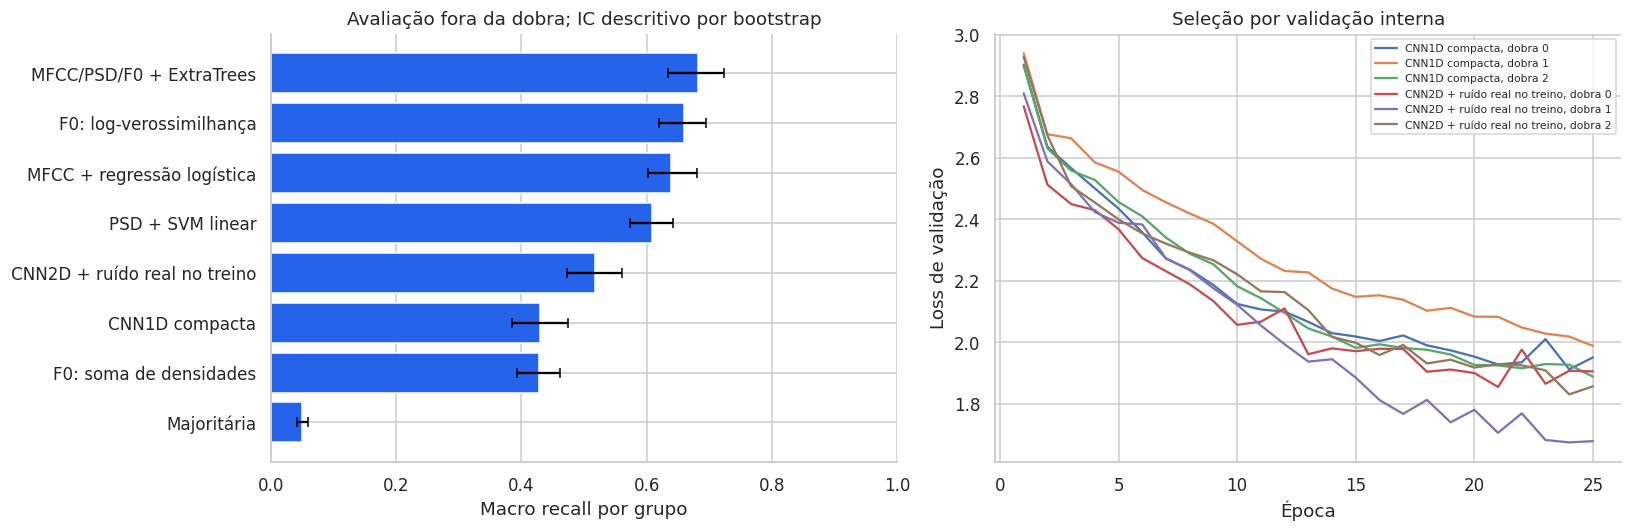

In [13]:
frontend = AudioFrontend().to(DEVICE)
with torch.no_grad():
    check = frontend(torch.from_numpy(np.array(WAVES[:8], copy=True)).to(DEVICE)).cpu().numpy()
frontend_error = float(np.max(np.abs(check - MEL[:8])))
assert frontend_error < 1e-4, f"Frontends SciPy/Torch divergem: {frontend_error}"
print("Diferença máxima entre frontends:", frontend_error)
CNN_MODELS, CNN_HISTORIES = {}, {}
for name, dimensions, augmented, tag in [
    ("CNN1D compacta", 1, False, "species_cnn1d"),
    ("CNN2D + ruído real no treino", 2, True, "species_cnn2d_noise"),
]:
    probabilities = np.zeros((len(PRIMARY), len(SPECIES)), dtype="float32")
    trained, histories = [], []
    for fold in range(CONFIG["folds"]):
        train = PRIMARY[fold_ids[PRIMARY] != fold]
        locations = np.flatnonzero(fold_ids[PRIMARY] == fold)
        test = PRIMARY[locations]
        model, history = train_cnn(train, test, Y_SPECIES, SPECIES, dimensions, augmented, tag, fold)
        probabilities[locations] = cnn_predict(model, WAVES[test])
        trained.append(model); histories.append(history)
    CNN_MODELS[name], CNN_HISTORIES[name] = trained, histories
    OOF[name] = probabilities
    predictions = aggregate_recordings(PRIMARY, Y_SPECIES[PRIMARY], probabilities, SPECIES)
    RECORDINGS[name] = predictions
    predictions.to_csv(RESULTS / f"predictions_{tag}.csv", index=False)
    low, high = bootstrap_macro_recall(predictions)
    summary_rows.append(dict(model=name, task="species", n_classes=len(SPECIES), n_windows=len(PRIMARY),
                             n_groups=len(predictions), **metrics(Y_SPECIES[PRIMARY], probabilities.argmax(axis=1)),
                             recording_macro_recall=balanced_accuracy_score(predictions.true, predictions.predicted),
                             ci_low=low, ci_high=high,
                             training_seconds=sum(torch.load(RESULTS / "models" / f"{tag}_fold{k}.pt",
                                                              map_location="cpu", weights_only=True)["training_seconds"]
                                                  for k in range(CONFIG["folds"]))))
benchmark = pd.DataFrame(summary_rows)
benchmark.to_csv(RESULTS / "species_metrics.csv", index=False)
np.savez_compressed(RESULTS / "species_oof_probabilities.npz",
                    **{f"model_{k}": probabilities for k, probabilities in enumerate(OOF.values())})
display(benchmark.round(4))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = benchmark.sort_values("recording_macro_recall")
positions = np.arange(len(order))
axes[0].barh(positions, order.recording_macro_recall, color="#2563eb")
axes[0].errorbar(order.recording_macro_recall, positions,
                 xerr=np.stack([order.recording_macro_recall-order.ci_low,
                                order.ci_high-order.recording_macro_recall]).clip(0),
                 fmt="none", color="black", capsize=3)
axes[0].set(yticks=positions, yticklabels=order.model, xlim=(0, 1),
            xlabel="Macro recall por grupo", title="Avaliação fora da dobra; IC descritivo por bootstrap")
for name, histories in CNN_HISTORIES.items():
    for fold, history in enumerate(histories):
        frame = pd.DataFrame(history)
        axes[1].plot(frame.epoch, frame.validation_loss, label=f"{name}, dobra {fold}")
axes[1].set(xlabel="Época", ylabel="Loss de validação", title="Seleção por validação interna")
axes[1].legend(fontsize=7)
plt.tight_layout()
save_figure("species_benchmark")

## 9. Tarefa inspirada no TinyML: quatro classes

Usamos **aegypti**, **albopictus**, **other** e **noise** com ruídos reais.
Cortes da mesma fonte de ruído ficam juntos. A rede recebe somente ruídos de treino.
Partições e distribuição de classes diferem da tarefa de 20 espécies e do subconjunto
de 93,8% do artigo; os percentuais não são diretamente comparáveis.
**Other** reúne espécies conhecidas no acervo, sem validar insetos desconhecidos.
Os ruídos não cobrem toda a diversidade ambiental.

tinyml_cnn1d, dobra 0: checkpoint validado e reutilizado


tinyml_cnn1d, dobra 1: checkpoint validado e reutilizado


tinyml_cnn1d, dobra 2: checkpoint validado e reutilizado


,model,n_classes,n_windows,n_groups,accuracy,balanced_accuracy,macro_f1,recording_macro_recall,ci_low,ci_high
0,MFCC + logística (4 classes),4,24405,613,0.5982,0.6536,0.3469,0.7843,0.6936,0.8540
1,CNN1D compacta (4 classes),4,24405,613,0.3510,0.5777,0.2629,0.6176,0.5133,0.7127


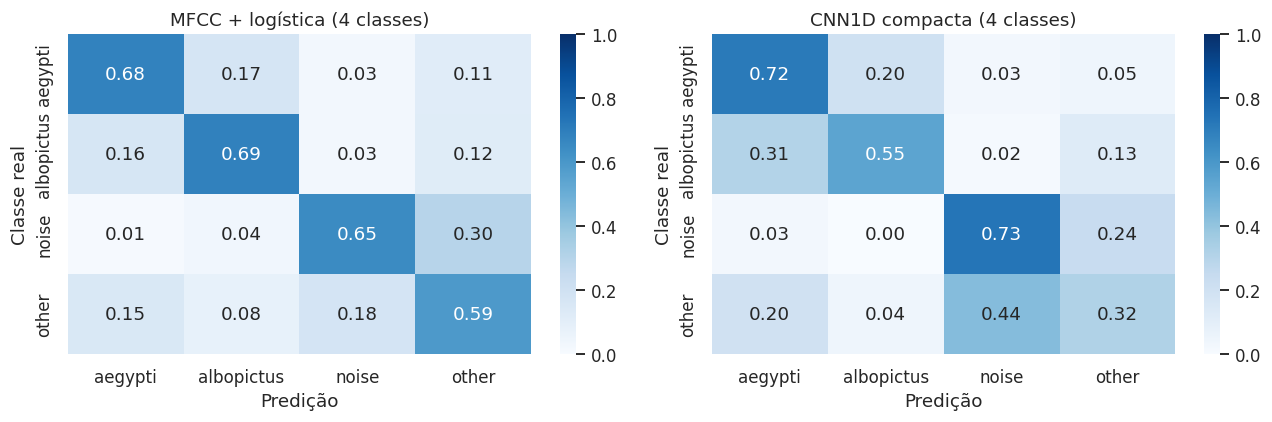

In [14]:
TINY = np.flatnonzero(tiny_folds >= 0)
tiny_probabilities = {}
tiny_models = {}
tiny_rows = []
for name, neural in [("MFCC + logística (4 classes)", False), ("CNN1D compacta (4 classes)", True)]:
    probabilities = np.zeros((len(TINY), 4), dtype="float32")
    models = []
    for fold in range(CONFIG["folds"]):
        train = TINY[tiny_folds[TINY] != fold]
        locations = np.flatnonzero(tiny_folds[TINY] == fold)
        test = TINY[locations]
        assert set(segments.iloc[train].group).isdisjoint(segments.iloc[test].group)
        if neural:
            model, _ = train_cnn(train, test, Y_TINY, TINY_NAMES, 1, True, "tinyml_cnn1d", fold)
            probabilities[locations] = cnn_predict(model, WAVES[test])
        else:
            model = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=3000, random_state=SEED))
            model.fit(X[train][:, MFCC_COLUMNS], Y_TINY[train],
                      logisticregression__sample_weight=group_weights(train, Y_TINY))
            probabilities[locations] = model.predict_proba(X[test][:, MFCC_COLUMNS])
        models.append(model)
    tiny_models[name] = models
    tiny_probabilities[name] = probabilities
    recordings = aggregate_recordings(TINY, Y_TINY[TINY], probabilities, TINY_NAMES)
    recordings.to_csv(RESULTS / f"tinyml_predictions_{int(neural)}.csv", index=False)
    low, high = bootstrap_macro_recall(recordings)
    tiny_rows.append(dict(model=name, n_classes=4, n_windows=len(TINY), n_groups=len(recordings),
                          **metrics(Y_TINY[TINY], probabilities.argmax(1)),
                          recording_macro_recall=balanced_accuracy_score(recordings.true, recordings.predicted),
                          ci_low=low, ci_high=high))
tiny_summary = pd.DataFrame(tiny_rows)
tiny_summary.to_csv(RESULTS / "tinyml_metrics.csv", index=False)
display(tiny_summary.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (name, probabilities), ax in zip(tiny_probabilities.items(), axes):
    matrix = confusion_matrix(Y_TINY[TINY], probabilities.argmax(1), labels=np.arange(4), normalize="true")
    sns.heatmap(matrix, vmin=0, vmax=1, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=TINY_NAMES, yticklabels=TINY_NAMES, ax=ax)
    ax.set(title=name, xlabel="Predição", ylabel="Classe real")
plt.tight_layout()
save_figure("tinyml_confusion")

## 10. Teste com aparelho não visto

Reservamos um aparelho inteiro e treinamos com outros. Avaliamos espécies presentes
no teste e com pelo menos dois grupos no treino; o número de classes varia.
Grupos compartilhados são retirados do treino.
O teste ainda mistura população/sexo/ambiente/coleta. Resultados com conjuntos diferentes
de espécies não são um ranking causal de qualidade dos microfones.

In [15]:
transfer_rows, transfer_predictions = [], []
all_species = np.flatnonzero(Y_SPECIES >= 0)
phones = sorted(set(segments.iloc[all_species].phone) - {"unknown"})
for phone in phones:
    test_candidate = all_species[segments.iloc[all_species].phone.eq(phone).to_numpy()]
    train_candidate = all_species[segments.iloc[all_species].phone.ne(phone).to_numpy()]
    test_labels = set(Y_SPECIES[test_candidate])
    support_train = segments.iloc[train_candidate].assign(target=Y_SPECIES[train_candidate]).groupby("target").group.nunique()
    common = sorted(test_labels & set(support_train[support_train >= 2].index))
    if len(common) < 2:
        continue
    test = test_candidate[np.isin(Y_SPECIES[test_candidate], common)]
    test_groups = set(segments.iloc[test].group)
    train = train_candidate[np.isin(Y_SPECIES[train_candidate], common) &
                            ~segments.iloc[train_candidate].group.isin(test_groups).to_numpy()]
    assert set(segments.iloc[train].group).isdisjoint(test_groups)
    assert len(set(Y_SPECIES[train])) == len(common)
    model = ExtraTreesClassifier(n_estimators=200, min_samples_leaf=2, max_features="sqrt",
                                  n_jobs=4, random_state=SEED)
    model.fit(X[train], Y_SPECIES[train], sample_weight=group_weights(train, Y_SPECIES))
    raw = model.predict_proba(X[test])
    full = np.zeros((len(test), len(SPECIES)))
    full[:, model.classes_] = raw
    recordings = aggregate_recordings(test, Y_SPECIES[test], full, SPECIES)
    recordings["held_out_phone"] = phone
    transfer_predictions.append(recordings)
    transfer_rows.append(dict(phone=phone, n_classes=len(common), n_windows=len(test),
                              n_groups=len(recordings), **metrics(Y_SPECIES[test], full.argmax(1)),
                              recording_macro_recall=balanced_accuracy_score(recordings.true, recordings.predicted)))
transfer_summary = pd.DataFrame(transfer_rows)
transfer_summary.to_csv(RESULTS / "device_transfer_metrics.csv", index=False)
if transfer_predictions:
    pd.concat(transfer_predictions).to_csv(RESULTS / "device_transfer_predictions.csv", index=False)
display(transfer_summary.round(4))

,phone,n_classes,n_windows,n_groups,accuracy,balanced_accuracy,macro_f1,recording_macro_recall
0,Huawei866C,7,1688,53,0.1517,0.1707,0.1366,0.2272
1,Nexus,12,2804,70,0.2496,0.2015,0.2098,0.1987
2,Nokia5235,7,2067,40,0.2753,0.2992,0.2521,0.4750
3,Nokia6555B,7,1829,33,0.2548,0.2782,0.2448,0.4190
4,T209,13,5293,91,0.1459,0.1746,0.1165,0.2055
5,Xperia,15,3068,59,0.2575,0.2433,0.2131,0.3154
6,iPhone,2,568,11,0.9525,0.9534,0.9524,1.0000
7,iPhone4S,9,2844,75,0.2447,0.2161,0.1789,0.2781
8,iPhone6,8,1864,45,0.3664,0.3553,0.3304,0.4958


## 11. Teste de estresse com ruído reservado

Selecionamos previamente até oito janelas por espécie/dobra. Acrescentamos ruído a
20, 10 e 0 dB: fontes reais reservadas na dobra de teste e ruído gaussiano.
Usamos os modelos já treinados, sem ajustar no teste.
SNR é relativo ao **áudio observado**, que já pode conter ruído, e não ao mosquito puro.
Mistura controlada não equivale a validação prospectiva em campo.
Curvas representam médias das dobras, sem teste de significância.

balanced_accuracy  \
model                        noise                added_snr_db                      
CNN2D + ruído real no treino ruído gaussiano      0                        0.1417   
                                                  10                       0.2708   
                                                  20                       0.4146   
                             ruído real reservado 0                        0.2312   
                                                  10                       0.3562   
                                                  20                       0.4292   
MFCC/PSD/F0 + ExtraTrees     ruído gaussiano      0                        0.2146   
                                                  10                       0.3250   
                                                  20                       0.4833   
                             ruído real reservado 0                        0.2104   
                                                  10                       0.4083   
                                                  20                       0.5021   

                                                                macro_f1  
model                        noise                added_snr_db            
CNN2D + ruído real no treino ruído gaussiano      0               0.0775  
                                                  10              0.2126  
                                                  20              0.3784  
                             ruído real reservado 0               0.2125  
                                                  10              0.3207  
                                                  20              0.3977  
MFCC/PSD/F0 + ExtraTrees     ruído gaussiano      0               0.1649  
                                                  10              0.2977  
                                                  20              0.4822  
                             ruído real reservado 0               0.2036  
                                                  10              0.4157  
                                                  20              0.5044

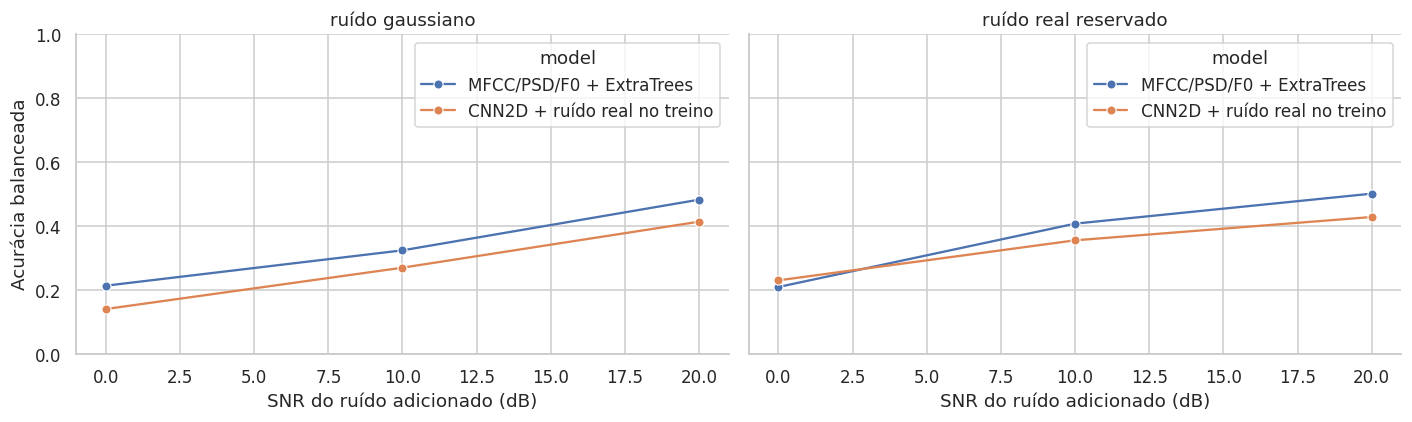

In [16]:
ROBUST_CLASSIC = "MFCC/PSD/F0 + ExtraTrees"
ROBUST_CNN = "CNN2D + ruído real no treino"
robustness_rows = []
for fold in range(CONFIG["folds"]):
    rng = np.random.default_rng(SEED + fold)
    test = PRIMARY[fold_ids[PRIMARY] == fold]
    # Small pre-specified, balanced probe; selection does not inspect predictions.
    chosen = np.concatenate([rng.choice(test[Y_SPECIES[test] == label],
                                        min(8, np.sum(Y_SPECIES[test] == label)), replace=False)
                             for label in range(len(SPECIES))])
    noise_test = np.flatnonzero(segments.label.eq("noise").to_numpy() & (fold_ids == fold))
    assert len(noise_test)
    outer_train = PRIMARY[fold_ids[PRIMARY] != fold]
    assert set(segments.iloc[noise_test].group).isdisjoint(segments.iloc[outer_train].group)
    environmental_noise = np.asarray(WAVES[rng.choice(noise_test, len(chosen), replace=True)])
    gaussian_noise = rng.normal(size=(len(chosen), SR)).astype("float32")
    gaussian_noise /= np.sqrt(np.mean(gaussian_noise**2, axis=1, keepdims=True))
    for kind, background in [("ruído real reservado", environmental_noise), ("ruído gaussiano", gaussian_noise)]:
        for snr in [20, 10, 0]:
            mixed = (np.asarray(WAVES[chosen]) + background * 10 ** (-snr / 20)).astype("float32")
            noisy_features = np.stack([wave_features(wave)[0] for wave in mixed])
            classic = CLASSICAL_MODELS[ROBUST_CLASSIC][fold].predict(noisy_features)
            neural = cnn_predict(CNN_MODELS[ROBUST_CNN][fold], mixed).argmax(1)
            for name, predicted in [(ROBUST_CLASSIC, classic), (ROBUST_CNN, neural)]:
                robustness_rows.append(dict(model=name, fold=fold, noise=kind, added_snr_db=snr,
                                            n_windows=len(chosen), **metrics(Y_SPECIES[chosen], predicted)))
robustness = pd.DataFrame(robustness_rows)
robustness.to_csv(RESULTS / "noise_robustness.csv", index=False)
display(robustness.groupby(["model", "noise", "added_snr_db"])[["balanced_accuracy", "macro_f1"]].mean().round(4))
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for (kind, rows), ax in zip(robustness.groupby("noise"), axes):
    sns.lineplot(data=rows, x="added_snr_db", y="balanced_accuracy", hue="model",
                 marker="o", errorbar=None, ax=ax)
    ax.set(title=kind, xlabel="SNR do ruído adicionado (dB)", ylabel="Acurácia balanceada", ylim=(0, 1))
plt.tight_layout()
save_figure("noise_robustness")

## 12. Abstenção e confundimento da aquisição

Limiares predefinidos mostram cobertura/acerto das amostras aceitas. Escores não foram
calibrados para campo. O teste só usa espécies conhecidas e não demonstra detecção
de espécie desconhecida.

Um diagnóstico separado usa somente aparelho e taxa declarada no cabeçalho.
O encoding é ajustado no treino; nomes de espécies/pastas são excluídos.
Desempenho sem áudio revela associações da aquisição com os rótulos.

In [17]:
probabilities = OOF["MFCC + regressão logística"]
max_scores = probabilities.max(axis=1)
selective_rows = []
for threshold in [0, .3, .5, .7, .9]:
    accepted = max_scores >= threshold
    selective_rows.append(dict(threshold=threshold, coverage=accepted.mean(),
                               accepted_windows=int(accepted.sum()),
                               accepted_accuracy=accuracy_score(Y_SPECIES[PRIMARY][accepted],
                                                                 probabilities[accepted].argmax(1)) if accepted.any() else np.nan))
selective = pd.DataFrame(selective_rows)
selective.to_csv(RESULTS / "selective_classification.csv", index=False)
display(selective.round(4))
# This baseline uses ONLY sampling metadata to expose acquisition confounding.
metadata_frame = segments[["phone"]].copy()
metadata_frame["header_rate"] = segments.path.map(inventory.set_index("path").sample_rate).astype(str)
metadata_predictions = np.full(len(PRIMARY), -1)
for fold in range(CONFIG["folds"]):
    train = PRIMARY[fold_ids[PRIMARY] != fold]
    positions = np.flatnonzero(fold_ids[PRIMARY] == fold)
    test = PRIMARY[positions]
    metadata_train = pd.get_dummies(metadata_frame.iloc[train], dtype=float)
    metadata_test = pd.get_dummies(metadata_frame.iloc[test], dtype=float).reindex(columns=metadata_train.columns, fill_value=0)
    model = LogisticRegression(C=1, max_iter=1000, random_state=SEED)
    model.fit(metadata_train, Y_SPECIES[train], sample_weight=group_weights(train, Y_SPECIES))
    metadata_predictions[positions] = model.predict(metadata_test)
metadata_diagnostic = metrics(Y_SPECIES[PRIMARY], metadata_predictions)
(RESULTS / "metadata_diagnostic.json").write_text(json.dumps(metadata_diagnostic, indent=2))
print("Diagnóstico de confundimento: desempenho sem usar áudio", metadata_diagnostic)
# Only phone and header sampling rate are used; folder species names are excluded.

,threshold,coverage,accepted_windows,accepted_accuracy
0,0.0,1.0000,23877,0.3396
1,0.3,0.6407,15297,0.4155
2,0.5,0.2989,7136,0.5443
3,0.7,0.1597,3813,0.6446
4,0.9,0.0723,1727,0.7574


Diagnóstico de confundimento: desempenho sem usar áudio {'accuracy': 0.11952925409389789, 'balanced_accuracy': 0.23528845484082545, 'macro_f1': 0.12280913563456956}


## 13. INT8 e exportação C

Quantizamos os pesos da logística MFCC por classe e entradas padronizadas por escala global;
a calibração usa treino. Entradas/pesos são INT8, acumulação INT32, bias/escalas finais float.
Comparamos previsões fora da dobra com o modelo original.

Exportamos **mosquito_mfcc_int8.h**, compilamos C e comparamos 400 previsões contra Python.
O arquivo é o modelo da dobra 0. O payload exclui frontend áudio/MFCC, FFT, firmware,
strings, RAM de trabalho e hardware. A validação é local; não mede Arduino/TFLite/EON.

In [18]:
def quantize_logistic(model, calibration):
    scaler, classifier = model.steps[0][1], model.steps[-1][1]
    mean = scaler.mean_.astype("float32")
    inverse_std = (1 / scaler.scale_).astype("float32")
    normalized = (calibration.astype("float32") - mean) * inverse_std
    input_scale = np.array(max(np.quantile(np.abs(normalized), .999) / 127, 1e-8), dtype="float32")
    weights = classifier.coef_.astype("float32")
    weight_scale = np.maximum(np.max(np.abs(weights), axis=1) / 127, 1e-8).astype("float32")
    return dict(mean=mean, inverse_std=inverse_std, input_scale=input_scale,
                weights=np.clip(np.rint(weights / weight_scale[:, None]), -127, 127).astype("int8"),
                weight_scale=weight_scale, bias=classifier.intercept_.astype("float32"))

def quantized_predict(payload, features, return_scores=False):
    normalized = (features.astype("float32") - payload["mean"]) * payload["inverse_std"]
    integer_input = np.clip(np.rint(normalized / payload["input_scale"]), -127, 127).astype("int8")
    accumulators = integer_input.astype("int32") @ payload["weights"].astype("int32").T
    scores = accumulators.astype("float32") * payload["input_scale"] * payload["weight_scale"] + payload["bias"]
    return scores if return_scores else scores.argmax(axis=1)

def c_float(value):
    text = format(float(value), ".9g")
    if "." not in text and "e" not in text:
        text += ".0"
    return text + "f"

def export_c(payload):
    count_classes, count_features = payload["weights"].shape
    parts = ["/* MFCC INT8 classifier, fold 0. Audio/MFCC frontend is required separately. */",
             "#ifndef MOSQUITO_MFCC_INT8_H", "#define MOSQUITO_MFCC_INT8_H",
             "#include <stdint.h>", "#include <math.h>",
             f"#define MOSQUITO_CLASSES {count_classes}", f"#define MOSQUITO_FEATURES {count_features}"]
    for name in ["mean", "inverse_std", "weight_scale", "bias"]:
        values = ", ".join(c_float(x) for x in payload[name])
        parts.append(f"static const float mosquito_{name}[{len(payload[name])}] = {{{values}}};")
    parts.append(f"static const float mosquito_input_scale = {c_float(payload['input_scale'])};")
    rows = ",\n".join("{" + ", ".join(str(int(x)) for x in row) + "}" for row in payload["weights"])
    parts.append(f"static const int8_t mosquito_weights[MOSQUITO_CLASSES][MOSQUITO_FEATURES] = {{\n{rows}\n}};")
    parts.append("""
static int mosquito_predict_mfcc(const float input[MOSQUITO_FEATURES]) {
    int8_t quantized[MOSQUITO_FEATURES];
    for (int j = 0; j < MOSQUITO_FEATURES; ++j) {
        float z = (input[j] - mosquito_mean[j]) * mosquito_inverse_std[j] / mosquito_input_scale;
        long value = lrintf(z);
        if (value > 127) value = 127;
        if (value < -127) value = -127;
        quantized[j] = (int8_t)value;
    }
    int best = 0;
    float best_score = -INFINITY;
    for (int k = 0; k < MOSQUITO_CLASSES; ++k) {
        int32_t accumulator = 0;
        for (int j = 0; j < MOSQUITO_FEATURES; ++j)
            accumulator += (int32_t)quantized[j] * mosquito_weights[k][j];
        float score = (float)accumulator * mosquito_input_scale * mosquito_weight_scale[k] + mosquito_bias[k];
        if (score > best_score) { best_score = score; best = k; }
    }
    return best;
}
#endif
""")
    header = RESULTS / "models/mosquito_mfcc_int8.h"
    header.write_text("\n".join(parts))
    demo = RESULTS / "models/mosquito_mfcc_int8_demo.c"
    demo.write_text('#include <stdio.h>\n#include "mosquito_mfcc_int8.h"\nint main(void) {\n'
                    'float input[MOSQUITO_FEATURES];\nwhile (1) {\n'
                    'for (int j=0;j<MOSQUITO_FEATURES;++j) if (scanf("%f",&input[j])!=1) return 0;\n'
                    'printf("%d\\n",mosquito_predict_mfcc(input));\n}\n}\n')
    return header, demo

In [19]:
quantized_predictions = np.full(len(PRIMARY), -1)
quantized_payloads = []
for fold in range(CONFIG["folds"]):
    train = PRIMARY[fold_ids[PRIMARY] != fold]
    locations = np.flatnonzero(fold_ids[PRIMARY] == fold)
    test = PRIMARY[locations]
    payload = quantize_logistic(CLASSICAL_MODELS["MFCC + regressão logística"][fold], X[train][:, MFCC_COLUMNS])
    quantized_payloads.append(payload)
    quantized_predictions[locations] = quantized_predict(payload, X[test][:, MFCC_COLUMNS])
    np.savez_compressed(RESULTS / "models" / f"mfcc_int8_fold{fold}.npz", **payload)
float_predictions = OOF["MFCC + regressão logística"].argmax(1)
quantized_metrics = metrics(Y_SPECIES[PRIMARY], quantized_predictions)
float_metrics = metrics(Y_SPECIES[PRIMARY], float_predictions)
quantization = pd.DataFrame([dict(precision="Logística original (float)", **float_metrics),
                             dict(precision="INT8 / acumulador INT32", **quantized_metrics)])
quantization.to_csv(RESULTS / "int8_metrics.csv", index=False)
display(quantization.round(4))
print("Concordância original/INT8:", round(np.mean(float_predictions == quantized_predictions), 4))
payload = quantized_payloads[0]
payload_bytes = sum(value.nbytes for value in payload.values())
header, c_demo = export_c(payload)
binary = CACHE / "mosquito_mfcc_int8_demo"
compile_check = subprocess.run(["cc", "-O2", str(c_demo), "-lm", "-o", str(binary)], capture_output=True, text=True)
assert compile_check.returncode == 0, compile_check.stderr
c_test = PRIMARY[fold_ids[PRIMARY] == 0][:400]
features = X[c_test][:, MFCC_COLUMNS]
input_text = "\n".join(" ".join(format(float(value), ".9g") for value in row) for row in features) + "\n"
process = subprocess.run([str(binary)], input=input_text, text=True, capture_output=True, check=True)
c_predictions = np.array([int(value) for value in process.stdout.split()])
np.testing.assert_array_equal(c_predictions, quantized_predict(payload, features))
quantization_audit = dict(payload_bytes=payload_bytes, c_python_matching_predictions=len(c_test),
                           prediction_agreement=float(np.mean(float_predictions == quantized_predictions)),
                           original_float_metrics=float_metrics, int8_metrics=quantized_metrics,
                           maximum_int32_accumulator=len(MFCC_COLUMNS) * 127 * 127)
(RESULTS / "int8_audit.json").write_text(json.dumps(quantization_audit, indent=2))
print("Payload de pesos + escalas + padronização:", payload_bytes, "bytes")
print("Exportação C compilada: 400/400 previsões iguais às do Python.")
print("Esses números excluem o frontend de áudio/MFCC, firmware e RAM de processamento.")

,precision,accuracy,balanced_accuracy,macro_f1
0,Logística original (float),0.3396,0.4794,0.3810
1,INT8 / acumulador INT32,0.3394,0.4793,0.3808


Concordância original/INT8: 0.9775
Payload de pesos + escalas + padronização: 892 bytes
Exportação C compilada: 400/400 previsões iguais às do Python.
Esses números excluem o frontend de áudio/MFCC, firmware e RAM de processamento.


## 14. Classificar outra gravação

**classify_recording("arquivo.wav")** decodifica, reamostra e agrega escores.
A demonstração usa um arquivo inteiro reservado na dobra 0 e seu modelo.
Para novos dados, confirme qualidade, taxonomia e coleta. O rótulo da pasta não garante
mosquito em cada segundo; limiares de abstenção ainda precisam de validação externa.

In [20]:
def classify_recording(path, minimum_score=.7, fold=0):
    path = Path(path).expanduser().resolve()
    wave = read_wave({"path": str(path), "sha256": sha256_file(path)})
    count = len(wave) // SR
    if count < 1:
        raise ValueError("A gravação precisa ter pelo menos 1 segundo.")
    features = np.stack([wave_features(wave[position * SR:(position + 1) * SR])[0]
                         for position in range(count)])
    model = CLASSICAL_MODELS["MFCC + regressão logística"][fold]
    scores = model.predict_proba(features[:, MFCC_COLUMNS]).mean(axis=0)
    ranking = pd.Series(scores, index=SPECIES).sort_values(ascending=False)
    return dict(prediction=str(ranking.index[0]) if ranking.iloc[0] >= minimum_score else "abster",
                score=float(ranking.iloc[0]), seconds_analyzed=count, ranking=ranking.head(5).to_dict())

demo_index = PRIMARY[fold_ids[PRIMARY] == 0][0]
demo_path = ROOT / segments.iloc[demo_index].path
demo_result = classify_recording(demo_path, fold=0)
print("Demonstração com arquivo da dobra 0, ausente do treino do modelo 0:")
print("Rótulo do arquivo:", segments.iloc[demo_index].label)
display(demo_result)

Demonstração com arquivo da dobra 0, ausente do treino do modelo 0:
Rótulo do arquivo: Aedes aegypti


{'prediction': 'abster',
 'score': 0.34848907739851076,
 'seconds_analyzed': 60,
 'ranking': {'Aedes aegypti': 0.34848907739851076,
  'Anopheles arabiensis': 0.26102495212161714,
  'Anopheles quadriannulatus': 0.13225654397664383,
  'Anopheles gambiae': 0.057964264868412864,
  'Aedes albopictus': 0.05297280504424588}}

## 15. Conclusões verificáveis

O maior macro recall observado abaixo depende deste acervo/protocolo. Selecionar o maior
entre vários modelos não produz uma estimativa imparcial de desempenho de um produto novo.
Consulte também aparelhos reservados, ruído e suporte por espécie.

A auditoria resolve duplicatas/relações verificáveis. Persistem dependências por
indivíduo/colônia e espécies concentradas em poucas sessões. Gravações longas têm rótulos
fracos e não passaram por anotação temporal independente de mosquito.

Para avançar: novas populações/sessões com identificação de espécimes, anotações de atividade,
sexo/temperatura, conjunto externo reservado, rejeição com espécies/ruídos desconhecidos
e medição do pipeline completo no hardware. Ganhos de classificação não podem ser
atribuídos exclusivamente à biologia do batimento alar.

Manifests registram origens, hashes, ambiente, configuração, cobertura, exclusões e checagens.
Tabelas, figuras e modelos são regenerados pelo notebook.

In [21]:
best = benchmark.sort_values("recording_macro_recall", ascending=False).iloc[0]
print(f"Maior macro recall observado por gravação: {best.model}, {best.recording_macro_recall:.1%}.")
print("A classificação é exploratória: gravação/colônia/aparelho/ambiente não são fatores independentes.")
session_counts = segments.iloc[PRIMARY].groupby("label").session.nunique()
display(session_counts.rename("Sessões inferidas por espécie"))
print("Casos em que uma única sessão inferida concentra a espécie:", session_counts[session_counts == 1].index.tolist())
integrity = {
    "generated_utc": datetime.now(timezone.utc).isoformat(), "config": CONFIG,
    "versions": versions, "python": sys.version, "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None,
    "download_total_bytes": sum(r["size"] for r in archives), "verified_archives": len(archives),
    "inventory_files": len(inventory), "usable_candidate_files": len(usable),
    "analyzed_windows": len(segments), "species_windows": len(PRIMARY),
    "species_groups": int(segments.iloc[PRIMARY].group.nunique()), "species": SPECIES.tolist(),
    "group_disjointness_asserted": True, "identical_waveform_disjointness_asserted": True,
    "frontend_maximum_absolute_error": frontend_error, "c_int8_checks": len(c_test),
    "gpu_bitwise_determinism_guaranteed": False,
    "exclusions": inventory.exclusion.replace("", "included").value_counts().to_dict(),
    "pdf_sha256": {f"paper_{k}.pdf": sha256_file(ROOT / "literature" / f"paper_{k}.pdf") for k in [1, 2, 3]
                   if (ROOT / "literature" / f"paper_{k}.pdf").exists()},
    "feature_cache": json.loads((CACHE / "features_manifest.json").read_text()),
}
(RESULTS / "run_manifest.json").write_text(json.dumps(integrity, indent=2, ensure_ascii=False))
files = [p for p in RESULTS.rglob("*") if p.is_file() and p.name != "sha256.json"]
(RESULTS / "sha256.json").write_text(json.dumps({str(p.relative_to(ROOT)): sha256_file(p) for p in files}, indent=2))
print("Resultados, modelos, gráficos e manifests salvos em: results/")

Maior macro recall observado por gravação: MFCC/PSD/F0 + ExtraTrees, 68.3%.
A classificação é exploratória: gravação/colônia/aparelho/ambiente não são fatores independentes.


label
Aedes aegypti                 6
Aedes albopictus              3
Aedes mediovittatus           1
Aedes sierrensis             11
Anopheles albimanus           8
Anopheles arabiensis          6
Anopheles atroparvus          3
Anopheles dirus               8
Anopheles farauti             8
Anopheles freeborni           8
Anopheles gambiae            17
Anopheles merus               1
Anopheles minimus             8
Anopheles quadriannulatus     3
Anopheles quadrimaculatus     2
Anopheles stephensi           8
Culex pipiens                 2
Culex quinquefasciatus        2
Culex tarsalis                2
Culiseta incidens             1
Name: Sessões inferidas por espécie, dtype: int64

Casos em que uma única sessão inferida concentra a espécie: ['Aedes mediovittatus', 'Anopheles merus', 'Culiseta incidens']


Resultados, modelos, gráficos e manifests salvos em: results/


In [22]:
display(Markdown(
    f"**Resultado da etapa inicial:** {len(SPECIES)} espécies, {len(PRIMARY):,} janelas e "
    f"{segments.iloc[PRIMARY].group.nunique()} grupos. O maior macro recall por grupo "
    f"foi **{best.recording_macro_recall:.1%}** com **{best.model}**.\n\n"
    f"**Generalização:** no teste com aparelhos não vistos e sete ou mais classes, "
    f"o macro recall por grupo variou de "
    f"**{transfer_summary.loc[transfer_summary.n_classes >= 7, 'recording_macro_recall'].min():.1%}** a "
    f"**{transfer_summary.loc[transfer_summary.n_classes >= 7, 'recording_macro_recall'].max():.1%}**. "
    f"Os conjuntos de espécies variam entre aparelhos. Apenas aparelho/taxa de amostragem "
    f"já alcançaram **{metadata_diagnostic['balanced_accuracy']:.1%}** "
    f"de acurácia balanceada por janela, mostrando associação entre aquisição e rótulo.\n\n"
    f"**INT8:** acurácia balanceada por janela de **{quantized_metrics['balanced_accuracy']:.1%}**, "
    f"payload de **{payload_bytes} bytes** e **{len(c_test)}/{len(c_test)}** "
    f"previsões C/Python correspondentes. Frontend e hardware não foram medidos."
))

**Resultado da etapa inicial:** 20 espécies, 23,877 janelas e 569 grupos. O maior macro recall por grupo foi **68.3%** com **MFCC/PSD/F0 + ExtraTrees**.

**Generalização:** no teste com aparelhos não vistos e sete ou mais classes, o macro recall por grupo variou de **19.9%** a **49.6%**. Os conjuntos de espécies variam entre aparelhos. Apenas aparelho/taxa de amostragem já alcançaram **23.5%** de acurácia balanceada por janela, mostrando associação entre aquisição e rótulo.

**INT8:** acurácia balanceada por janela de **47.9%**, payload de **892 bytes** e **400/400** previsões C/Python correspondentes. Frontend e hardware não foram medidos.

## 16. Melhorias executadas: contraste, dinâmica e novos modelos

Esta extensão reutiliza **as mesmas janelas e três dobras por grupo** da etapa inicial.
Acrescenta contraste espectral local em 75 frequências (média/desvio), variação temporal
de MFCC e rastreamento de pico: 181 características novas, 293 no total. O contraste
remove uma referência espectral local ampla; não garante remoção de ruído ou de
diferenças entre microfones. O RBF usa as 112 características originais; árvores,
boosting e MLP usam as 293. Mudam representação e modelo, sem isolar cada contribuição.

O ensemble combina RBF, ExtraTrees e boosting com pesos iguais fixados. A MLP
293 -> 128 -> 64 -> 20 tem validação interna por grupos. A comparação é uma
**reanálise adaptativa do corpus já utilizado**, não um novo teste externo.
O bootstrap pareado por grupo é descritivo e condicionado às previsões observadas.
Os algoritmos desta extensão estão nos scripts incluídos no repositório.

SVM RBF, dobra 0: 15862 treino / 8015 teste


SVM RBF, dobra 1: 15860 treino / 8017 teste


SVM RBF, dobra 2: 16032 treino / 7845 teste


Resultado: {"model": "SVM RBF", "accuracy": 0.46132261171839006, "balanced_accuracy": 0.5558163291238652, "macro_f1": 0.525136803820443, "recording_macro_recall": 0.766642400800552, "n_windows": 23877, "n_groups": 569, "training_seconds": 34.737309348012786}


ExtraTrees + contraste/dinâmica, dobra 0: 15862 treino / 8015 teste


...

Detecção: {"fold": 1, "mode": "Controle de alarmes por calibração", "presence_threshold": 0.9755962591482248, "window_recall": 0.2291380815766496, "window_false_positive_rate": 0.01764705882352941, "source_mean_recall": 0.22355083378158183, "source_mean_false_positive_rate": 0.031163558663558664, "window_balanced_accuracy": 0.6057455113765601, "positive_windows": 8017, "noise_windows": 340, "positive_groups": 189, "noise_groups": 15, "roc_auc": 0.8328738929774229}


Detecção: {"fold": 2, "mode": "Controle de alarmes por calibração", "presence_threshold": 0.982591008477754, "window_recall": 0.19094964945825366, "window_false_positive_rate": 0.017857142857142856, "source_mean_recall": 0.17190945213932193, "source_mean_false_positive_rate": 0.023809523809523808, "window_balanced_accuracy": 0.5865462533005554, "positive_windows": 7845, "noise_windows": 56, "positive_groups": 190, "noise_groups": 14, "roc_auc": 0.8614335791678047}


Melhorias executadas. Resultados: /home/lciarallo/Documentos/Git_projects/mosquito-wingbeat/results/improvements


,model,accuracy,balanced_accuracy,recording_macro_recall
0,ExtraTrees original (referência),0.4125,0.4892,0.6826
1,SVM RBF,0.4613,0.5558,0.7666
2,ExtraTrees + contraste/dinâmica,0.4774,0.5379,0.7284
3,HistGradientBoosting + contraste/dinâmica,0.5269,0.5850,0.7944
4,MLP compacta + contraste/dinâmica,0.4074,0.5160,0.7277
5,Ensemble fixo (RBF + árvores + boosting),0.5072,0.5900,0.7787


,model,paired_macro_recall_gain,descriptive_ci_low,descriptive_ci_high
0,SVM RBF,0.0840,0.0580,0.1126
1,ExtraTrees + contraste/dinâmica,0.0458,0.0197,0.0717
2,HistGradientBoosting + contraste/dinâmica,0.1118,0.0887,0.1361
3,MLP compacta + contraste/dinâmica,0.0450,0.0091,0.0828
4,Ensemble fixo (RBF + árvores + boosting),0.0961,0.0711,0.1239


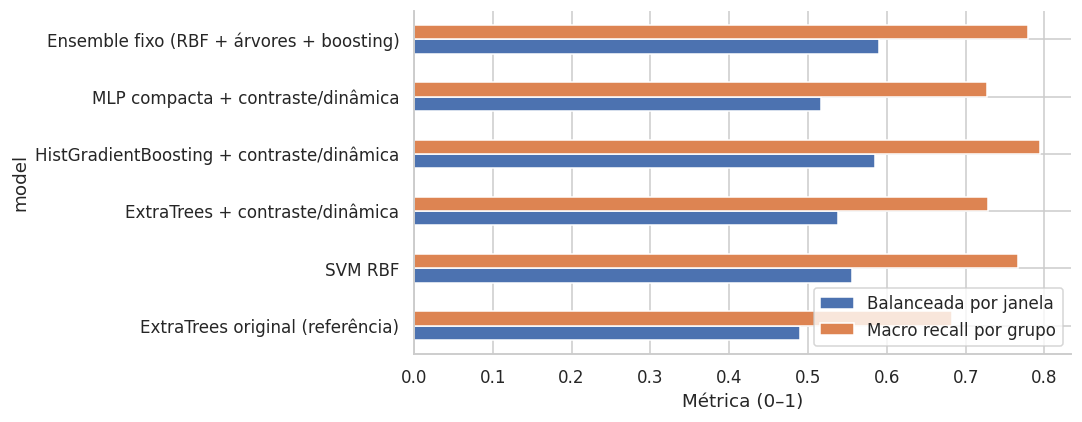

In [23]:
import improve_device
improve_device.main()
improved_metrics = pd.read_csv(RESULTS / "improvements/species_metrics.csv")
display(improved_metrics[["model", "accuracy", "balanced_accuracy", "recording_macro_recall"]].round(4))
display(pd.read_csv(RESULTS / "improvements/paired_group_differences.csv").round(4))
ax = improved_metrics.plot.barh(x="model", y=["balanced_accuracy", "recording_macro_recall"], figsize=(10, 4))
ax.set_xlabel("Métrica (0–1)"); ax.legend(["Balanceada por janela", "Macro recall por grupo"])
plt.tight_layout(); plt.show()

## 17. Presença de mosquito para Arduino: frontend completo e modelos compactos

Detecção binária e reconhecimento de 20 espécies são tarefas distintas. Os rótulos
de presença continuam **fracos, por arquivo**; não anotamos cada batimento/voo.
O novo frontend usa mono a 16 kHz, Hann de 512 amostras sem sobreposição e 31 frames
por decisão (**0,992 s**). Calcula 68 características de energia relativa, dispersão,
flatness e pico de 219–875 Hz. É incremental e não depende da normalização usando
uma janela inteira ou de áudio futuro. A implementação C++ guarda um frame de FFT.

Comparamos logística, árvore de profundidade 6, floresta de 32 árvores de profundidade 5
e uma **rede neural de 16 unidades ReLU** (1.121 parâmetros). Cada dobra externa
reserva grupos para calibração; outra divisão interna seleciona o candidato por ROC AUC
ponderada por fonte. A rede seleciona épocas por perda ponderada nessa validação interna
e treina novamente no conjunto de ajuste pelo mesmo número de épocas.
Padronizadores, calibradores, limiares e épocas não usam os grupos de teste externo.

A calibração binária usa pesos iguais para fontes positivas e negativas, equivalente
a uma mistura 50/50, **sem representar prevalência real**. Comparamos limiar 0,5
e metas de FPR médio por fonte de 5%/10% na calibração. Metas não garantem desempenho
no teste, e controlar alarmes pode perder sinais. Há somente 44 fontes de ruído.

                        model               mode  window_recall  window_false_positive_rate  source_mean_recall  source_mean_false_positive_rate  window_balanced_accuracy  positive_windows  noise_windows  positive_groups  noise_groups  roc_auc  source_recall_ci_low  source_recall_ci_high  source_false_positive_rate_ci_low  source_false_positive_rate_ci_high
Escolha por validação interna     Balanceado 0,5       0.826821                    0.352273            0.810195                         0.218421                  0.737274             23877            528              569            44 0.813391              0.789567               0.830278                           0.138035                            0.300769
Escolha por validação interna  Calibração FPR 5%       0.488839                    0.202652            0.482613                         0.092469                  0.643094             23877            528              569            44 0.813391              0.449805               

,model,mode,window_recall,window_false_positive_rate,source_mean_recall,source_mean_false_positive_rate
0,Logística streaming,"Balanceado 0,5",0.7593,0.3314,0.7342,0.2460
1,Logística streaming,Calibração FPR 5%,0.2126,0.0625,0.2074,0.0258
2,Logística streaming,Calibração FPR 10%,0.4489,0.1439,0.4309,0.0762
3,Árvore compacta,"Balanceado 0,5",0.6082,0.2879,0.6019,0.3909
4,Árvore compacta,Calibração FPR 5%,0.0000,0.0000,0.0000,0.0000
5,Árvore compacta,Calibração FPR 10%,0.0000,0.0000,0.0000,0.0000
6,Floresta compacta,"Balanceado 0,5",0.7556,0.4848,0.7305,0.2494
7,Floresta compacta,Calibração FPR 5%,0.3223,0.0398,0.3010,0.0389
8,Floresta compacta,Calibração FPR 10%,0.3742,0.0644,0.3487,0.0607
9,Rede neural 16 unidades,"Balanceado 0,5",0.8268,0.3523,0.8102,0.2184


,mode,source_recall_ci_low,source_recall_ci_high,source_false_positive_rate_ci_low,source_false_positive_rate_ci_high
12,"Balanceado 0,5",0.7896,0.8303,0.1380,0.3008
13,Calibração FPR 5%,0.4498,0.5158,0.0473,0.1413
14,Calibração FPR 10%,0.6849,0.7331,0.0886,0.2411


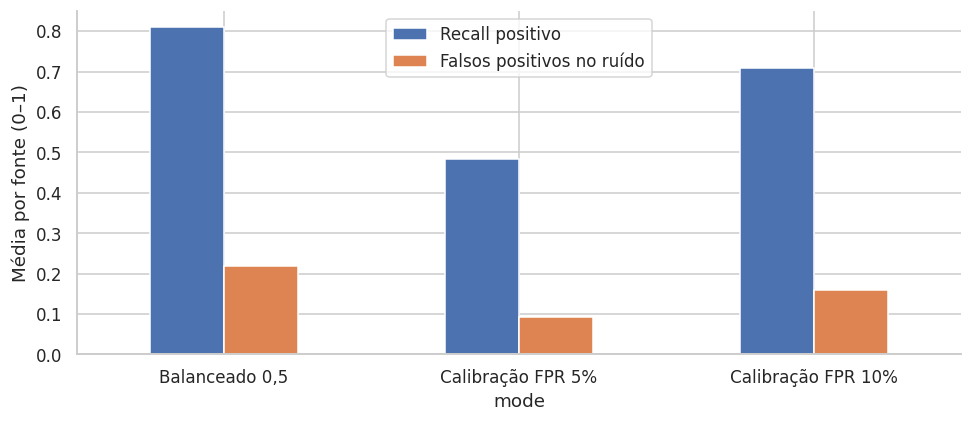

In [24]:
import train_arduino
train_arduino.main()
arduino_metrics = pd.read_csv(RESULTS / "arduino/metrics.csv")
display(arduino_metrics[["model", "mode", "window_recall", "window_false_positive_rate",
                         "source_mean_recall", "source_mean_false_positive_rate"]].round(4))
selected = arduino_metrics.loc[arduino_metrics.model.eq("Escolha por validação interna")]
display(selected[["mode", "source_recall_ci_low", "source_recall_ci_high",
                  "source_false_positive_rate_ci_low", "source_false_positive_rate_ci_high"]].round(4))
ax = selected.plot.bar(x="mode", y=["source_mean_recall", "source_mean_false_positive_rate"], figsize=(9, 4), rot=0)
ax.set_ylabel("Média por fonte (0–1)"); ax.legend(["Recall positivo", "Falsos positivos no ruído"])
plt.tight_layout(); plt.show()

### 17.1 Confirmação temporal e ruído persistente

A regra causal exige duas de três janelas completas e reinicia quando muda arquivo
ou há uma lacuna. Como o corpus amostra até 60 janelas por arquivo, muitas não são
contíguas. A comparação abaixo usa **os mesmos endpoints elegíveis** para uma janela
e para confirmação, sem tratar janelas espaçadas como áudio contínuo.
Restaram somente **duas fontes de ruído** nesse subconjunto; não há validação suficiente
de falsos alarmes contínuos. A correlação temporal pode manter ruídos como falsos positivos.
Estas taxas não permitem calcular alarmes/hora ou contar mosquitos individuais.

In [25]:
display(pd.read_csv(RESULTS / "arduino/persistence_metrics.csv").round(4))
import probe_arduino_noise
probe_arduino_noise.main()
arduino_noise = pd.read_csv(RESULTS / "arduino/noise_probe.csv")
display(arduino_noise.groupby(["mode", "noise", "added_snr_db"], dropna=False).positive_window_recall.mean().round(4))

,mode,rule,window_recall,window_false_positive_rate,source_mean_recall,source_mean_false_positive_rate,window_balanced_accuracy,positive_windows,noise_windows,positive_groups,noise_groups
0,"Balanceado 0,5",Uma janela no subconjunto contíguo,0.8647,0.5082,0.8347,0.7059,0.6782,18180,244,493,2
1,"Balanceado 0,5",2 de 3 janelas contíguas,0.8893,0.5082,0.8618,0.7059,0.6906,18180,244,493,2
2,Calibração FPR 5%,Uma janela no subconjunto contíguo,0.5322,0.2951,0.4995,0.1765,0.6185,18180,244,493,2
3,Calibração FPR 5%,2 de 3 janelas contíguas,0.5449,0.2787,0.5159,0.1667,0.6331,18180,244,493,2
4,Calibração FPR 10%,Uma janela no subconjunto contíguo,0.7798,0.4426,0.7345,0.6265,0.6686,18180,244,493,2
5,Calibração FPR 10%,2 de 3 janelas contíguas,0.8019,0.4385,0.7640,0.6542,0.6817,18180,244,493,2


mode                noise                 added_snr_db
Balanceado 0,5      Ruído real reservado  0.0             0.552083
                                          10.0            0.706250
                                          20.0            0.764583
                    Sem ruído adicionado  NaN             0.800000
Calibração FPR 10%  Ruído real reservado  0.0             0.402083
                                          10.0            0.583333
                                          20.0            0.672917
                    Sem ruído adicionado  NaN             0.702083
Calibração FPR 5%   Ruído real reservado  0.0             0.277083
                                          10.0            0.400000
                                          20.0            0.456250
                    Sem ruído adicionado  NaN             0.477083
Name: positive_window_recall, dtype: float64


mode                noise                 added_snr_db
Balanceado 0,5      Ruído real reservado  0.0             0.5521
                                          10.0            0.7062
                                          20.0            0.7646
                    Sem ruído adicionado  NaN             0.8000
Calibração FPR 10%  Ruído real reservado  0.0             0.4021
                                          10.0            0.5833
                                          20.0            0.6729
                    Sem ruído adicionado  NaN             0.7021
Calibração FPR 5%   Ruído real reservado  0.0             0.2771
                                          10.0            0.4000
                                          20.0            0.4562
                    Sem ruído adicionado  NaN             0.4771
Name: positive_window_recall, dtype: float64

## 18. Explicabilidade e validação do processamento embarcado

Permutamos cinco famílias de características em conjunto, cinco repetições por dobra,
e medimos a queda de ROC AUC ponderada por fonte nos dados de teste reservados.
Dentro da família, preservamos a relação entre características; entre famílias,
a permutação pode criar entradas incomuns. É uma análise de **sensibilidade preditiva**,
sem explicação causal, identificação biológica exclusiva ou atribuição local SHAP/Grad-CAM.
A dispersão abaixo combina dobras/repetições correlacionadas, não é intervalo inferencial.

,mean,std
family,,
Energia relativa 1125–4000 Hz,0.1752,0.0761
Energia relativa 125–1125 Hz,0.0908,0.0297
Flatness espectral,0.0186,0.0076
Pico 219–875 Hz,0.0384,0.0155
Variação temporal das bandas,0.0771,0.0200


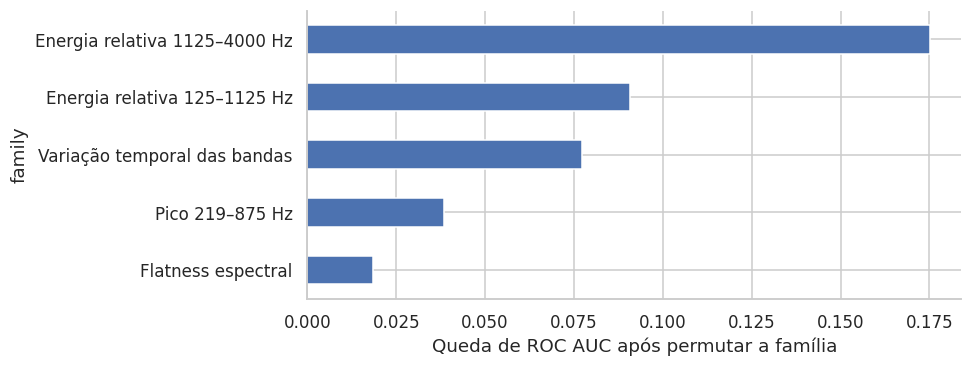

{
  "native_compiler_command": [
    "g++",
    "-std=c++11",
    "-O2",
    "-Wall",
    "-Wextra",
    "-Werror",
    "-shared",
    "-fPIC",
    "firmware/host_bridge.cpp",
    "-o",
    "tmp/arduino-verify/frontend.so"
  ],
  "tested_windows": 532,
  "heldout_positive_windows": 400,
  "heldout_noise_windows": 132,
  "max_absolute_feature_error": 3.4809112548828125e-05,
  "mean_absolute_feature_error": 2.3100396617792285e-07,
  "max_absolute_score_error": 8.717179298400879e-06,
  "matching_decisions": 532,
  "decision_agreement": 1.0,
  "tested_operating_mode": "Calibração FPR 10% (default firmware)",
  "streaming_frontend_object_bytes": 6420,
  "gain_and_dc_feature_max_error": 4.76837158203125e-07,
  "confirmation_and_gap_reset_tests_passed": true,
  "actual_board_flashing": false,
  "real_time_deadline_measured_on_board": false,
  "artifacts": {
    "firmware/host_bridge.cpp": "1eb75ec8828cb8d0cd77db7a99696b8fa8ffe07092ba07f9ea1c22dbb6aacc00",
    "firmware/README.md": "1bbff2e87b

,Auditoria nativa
native_compiler_command,"[g++, -std=c++11, -O2, -Wall, -Wextra, -Werror..."
tested_windows,532
heldout_positive_windows,400
heldout_noise_windows,132
max_absolute_feature_error,0.000035
mean_absolute_feature_error,0.0
max_absolute_score_error,0.000009
matching_decisions,532
decision_agreement,1.0
tested_operating_mode,Calibração FPR 10% (default firmware)


In [26]:
importance = pd.read_csv(RESULTS / "arduino/permutation_importance.csv")
importance_summary = importance.groupby("family").source_weighted_auc_drop.agg(["mean", "std"])
display(importance_summary.round(4))
importance_summary.sort_values("mean").plot.barh(y="mean", legend=False, figsize=(9, 3.5))
plt.xlabel("Queda de ROC AUC após permutar a família"); plt.tight_layout(); plt.show()
import verify_arduino
verify_arduino.main()
display(pd.Series(json.loads((RESULTS / "arduino/native_audit.json").read_text())).to_frame("Auditoria nativa"))

### 18.1 Firmware Arduino e limites do aparelho

O sketch [MosquitoPresence.ino](firmware/MosquitoPresence/MosquitoPresence.ino) captura
PDM, extrai características, executa a rede e confirma candidatos em 2/3 janelas.
Está compilado para **Arduino Nano 33 BLE Sense / Sense Rev2**, CLI 1.5.1/core 4.6.0.
O Uno R3/Nano clássico tem memória insuficiente para este firmware; outro modelo
Arduino exige seu adaptador de captura e nova compilação/avaliação.

**Não houve upload ou teste em placa física**. O compilador informa memória estática,
sem medir pico de pilha/heap, consumo ou prazo em tempo real. Os testes C++/Python
validam equivalência numérica e lógica. O modelo exportado é da dobra 0; o resultado
agregado usa cada modelo de sua própria dobra, sem retreino para produção.
O limiar moderado (meta 10% na calibração) é o padrão do sketch, antes da confirmação.
Os guardas de silêncio/clipping da captura ainda não têm taxas de campo medidas.
A primeira confirmação requer 2,976 s de áudio; passagens muito curtas podem ser
perdidas. Não há validação por voo isolado.

In [27]:
compile_path = RESULTS / "arduino/compile_audit.json"
if compile_path.exists():
    display(pd.Series(json.loads(compile_path.read_text())).to_frame("Compilação registrada"))
else:
    print("Para recompilar: arduino-cli compile --fqbn arduino:mbed_nano:nano33ble firmware/MosquitoPresence")
default = selected.loc[selected["mode"].eq("Calibração FPR 10%")].iloc[0]
display(Markdown(
    f"**O aparelho ainda erraria:** no teste com rótulos por arquivo, o modo padrão "
    f"perdeu **{1-default.window_recall:.1%}** dos trechos positivos e marcou "
    f"**{default.window_false_positive_rate:.1%}** dos trechos de ruído como candidatos, "
    f"antes da confirmação. Isso não estima erros por mosquito individual.\n\n"
    "Para melhorar de forma verificável: coletar áudio com a placa no ambiente real, "
    "anotar atividade/distância e horas sem mosquito, reservar dias/locais, treinar "
    "com os ruídos locais e medir sensibilidade por evento, falsos alarmes/hora e latência. "
    "Não há evidência de superioridade sobre os artigos com protocolos diferentes."
))

,Compilação registrada
board_fqbn,arduino:mbed_nano:nano33ble
target,Arduino Nano 33 BLE Sense / Sense Rev2
arduino_cli_version,1.5.1
core_version,4.6.0
compile_succeeded,True
program_storage_bytes,100832
global_static_memory_bytes,59584
maximum_program_storage_bytes,983040
maximum_ram_bytes,262144
global_memory_excludes_runtime_peak_stack_and_heap,True


**O aparelho ainda erraria:** no teste com rótulos por arquivo, o modo padrão perdeu **27.4%** dos trechos positivos e marcou **29.2%** dos trechos de ruído como candidatos, antes da confirmação. Isso não estima erros por mosquito individual.

Para melhorar de forma verificável: coletar áudio com a placa no ambiente real, anotar atividade/distância e horas sem mosquito, reservar dias/locais, treinar com os ruídos locais e medir sensibilidade por evento, falsos alarmes/hora e latência. Não há evidência de superioridade sobre os artigos com protocolos diferentes.

## 19. Identificação de 20 espécies no Nano 33 BLE Sense

O novo sketch [MosquitoSpecies.ino](firmware/MosquitoSpecies/MosquitoSpecies.ino)
usa o microfone PDM integrado e o mesmo frontend incremental de 68 características.
Uma rede indica presença; outro modelo escolhe entre as **20 espécies conhecidas**.
Comparamos logística 68 -> 20, MLP 68 -> 64 -> 20 e MLP 68 -> 128 -> 64 -> 20.
Todos cabem na memória da placa; o modelo escolhido pela validação interna varia
entre dobras. A época da rede usa perda em grupos internos; a seleção do candidato
usa acurácia ponderada por fonte/espécie. As fontes de calibração são as mesmas
reservadas na tarefa binária, para que o detector também não treine nesses áudios.

**Poucos grupos:** Aedes mediovittatus tem três grupos. Em cada dobra há um no teste,
um na calibração e um no ajuste. Esse último permanece no treino interno, sem
validação interna independente dessa espécie; os outros rótulos sustentam a seleção.
O protocolo registra essa limitação. Temperatura e limiar de abstenção usam apenas
grupos positivos de calibração, com pesos iguais para fontes/espécies. A meta é 80%
de acerto ponderado entre aceitos, cobertura ponderada mínima de 10% e 15 fontes.
Se a meta não é alcançada, aquela dobra rejeita todas as identificações.

O protótipo exportado é a **primeira dobra que atende à meta de calibração**;
nenhum resultado do teste determina essa escolha. Não há retreino em todo o corpus.
O benchmark agregado aplica a cada teste seu próprio modelo/limiares; a tabela
da dobra exportada abaixo permite distinguir o resultado desse firmware.

In [28]:
import train_arduino_species
train_arduino_species.main()
species_board = RESULTS / "arduino_species"
species_protocol = json.loads((species_board / "protocol.json").read_text())
species_compact = pd.read_csv(species_board / "metrics.csv")
display(species_compact.round(4))
display(pd.read_csv(species_board / "fold_metrics.csv").round(4))
display(pd.read_csv(species_board / "per_class.csv").round(4))
display(Markdown(f"**Dobra exportada:** {species_protocol['default_export_fold']}. "
                 "Veja os grupos, seleção, temperatura e busca do limiar em protocol.json."))

                        model  accuracy  balanced_accuracy  macro_f1  recording_accuracy  recording_macro_recall  positive_windows  positive_groups
            Logística 68 → 20  0.383675           0.502580  0.425818            0.578207                0.707811             23877              569
             MLP 68 → 64 → 20  0.396658           0.522254  0.447616            0.558875                0.686972             23877              569
       MLP 68 → 128 → 64 → 20  0.388952           0.523511  0.443171            0.558875                0.673141             23877              569
Escolha por validação interna  0.394564           0.521272  0.443300            0.574692                0.697612             23877              569


                                     rule  positive_windows  noise_windows  positive_groups  noise_groups  positive_coverage  noise_false_species_rate  positive_source_mean_coverage  noise_source_mean_false_species_rate  accepted_windows  accepted_positive_windows  accepted_noise_windows  accepted_accuracy_including_noise  accepted_positive_class_accuracy  correct_positive_fraction
         Uma janela: presença + confiança             23877            528              569            44           0.024501                       0.0                       0.026143                                   0.0               585                        585                       0                           0.769231                          0.769231                   0.018847
       Uma janela nos endpoints contíguos             18180            244              493             2           0.024917                       0.0                       0.022912                                   0.0           

,model,accuracy,balanced_accuracy,macro_f1,recording_accuracy,recording_macro_recall,positive_windows,positive_groups
0,Logística 68 → 20,0.3837,0.5026,0.4258,0.5782,0.7078,23877,569
1,MLP 68 → 64 → 20,0.3967,0.5223,0.4476,0.5589,0.6870,23877,569
2,MLP 68 → 128 → 64 → 20,0.3890,0.5235,0.4432,0.5589,0.6731,23877,569
3,Escolha por validação interna,0.3946,0.5213,0.4433,0.5747,0.6976,23877,569


,fold,model,accuracy,balanced_accuracy,macro_f1,recording_accuracy,recording_macro_recall,positive_windows,positive_groups
0,0,MLP 68 → 128 → 64 → 20,0.3960,0.5095,0.4481,0.5737,0.7027,8015,190
1,1,Logística 68 → 20,0.3658,0.5161,0.3970,0.5503,0.6938,8017,189
2,2,MLP 68 → 64 → 20,0.4224,0.5396,0.4873,0.6000,0.7030,7845,190


,species,windows,groups,recall,precision
0,Aedes aegypti,1200,20,0.5267,0.5012
1,Aedes albopictus,420,7,0.5357,0.2255
2,Aedes mediovittatus,180,3,0.8444,0.4780
3,Aedes sierrensis,227,60,0.6564,0.3318
4,Anopheles albimanus,2131,40,0.4388,0.3939
5,Anopheles arabiensis,780,13,0.1962,0.1972
6,Anopheles atroparvus,420,7,0.4976,0.4130
7,Anopheles dirus,2414,55,0.1988,0.2526
8,Anopheles farauti,2087,46,0.3019,0.3043
9,Anopheles freeborni,2623,54,0.3222,0.4248


**Dobra exportada:** 2. Veja os grupos, seleção, temperatura e busca do limiar em protocol.json.

### 19.1 Acurácia, cobertura e confirmação de espécie

O firmware só emite identificação provisória se há evidência de presença, o escore
da classe passa pelo limiar e a **mesma classe aparece em duas de três janelas**.
A janela atual deve ser elegível; uma janela incerta não repete um rótulo anterior.
Falhas de captura reiniciam a confirmação. A primeira decisão requer 2,976 s de
observação, além do tempo computacional. A espécie candidata aparece no serial
mesmo quando a decisão é INCERTO; o LED indica uma identificação emitida.

A rejeição aumenta o acerto **condicional**, mas perde muitos trechos. Não interpreta
o escore como probabilidade garantida de acerto. Classes ausentes do dataset podem
receber um nome conhecido. Acurácia por arquivo agrega vários trechos, diferindo
de um único som; nenhuma dessas taxas valida cada voo em campo.

No corpus, comparamos a confirmação somente nos mesmos endpoints contíguos, com
reset em arquivos/lacunas. Há só duas fontes de ruído nesse subconjunto agregado;
na dobra exportada não há nenhum trecho negativo elegível para confirmação.
Uma taxa zero observada antes da confirmação **não garante** zero alarmes em campo.
Os guardas de silêncio/clipping do microfone também não foram avaliados nesse teste.

In [29]:
display(pd.read_csv(species_board / "selective_metrics.csv").round(4))
display(pd.read_csv(species_board / "default_selective_metrics.csv").round(4))
display(pd.read_csv(species_board / "selective_per_class.csv").round(4))
compact_best = species_compact.loc[species_compact.model.eq("Escolha por validação interna")].iloc[0]
exported_fold = pd.read_csv(species_board / "fold_metrics.csv")
exported_fold = exported_fold.loc[exported_fold.fold.eq(species_protocol["default_export_fold"])].iloc[0]
default_selective = pd.read_csv(species_board / "default_selective_metrics.csv").iloc[-1]
display(Markdown(
    f"**Escolha forçada, agregado:** {compact_best.accuracy:.1%} de acerto geral por janela; "
    f"{compact_best.balanced_accuracy:.1%} de acurácia balanceada.\n\n"
    f"**Modelo exportado, escolha forçada:** {exported_fold.accuracy:.1%} geral e "
    f"{exported_fold.balanced_accuracy:.1%} balanceada na sua própria dobra de teste.\n\n"
    f"**Modelo exportado, confirmação e rejeição:** "
    f"{default_selective.accepted_positive_class_accuracy:.1%} de acerto entre "
    f"{int(default_selective.accepted_positive_windows)} identificações emitidas, "
    f"cobrindo apenas {default_selective.positive_coverage:.1%} dos "
    f"{int(default_selective.positive_windows)} endpoints positivos contíguos. "
    "Não é a acurácia em todos os sons nem uma medida na placa física."
))

,rule,positive_windows,noise_windows,positive_groups,noise_groups,positive_coverage,noise_false_species_rate,positive_source_mean_coverage,noise_source_mean_false_species_rate,accepted_windows,accepted_positive_windows,accepted_noise_windows,accepted_accuracy_including_noise,accepted_positive_class_accuracy,correct_positive_fraction
0,Uma janela: presença + confiança,23877,528,569,44,0.0245,0.0,0.0261,0.0,585,585,0,0.7692,0.7692,0.0188
1,Uma janela nos endpoints contíguos,18180,244,493,2,0.0249,0.0,0.0229,0.0,453,453,0,0.7748,0.7748,0.0193
2,2/3 mesma espécie nos endpoints contíguos,18180,244,493,2,0.0127,0.0,0.0116,0.0,231,231,0,0.8788,0.8788,0.0112


,rule,positive_windows,noise_windows,positive_groups,noise_groups,positive_coverage,noise_false_species_rate,positive_source_mean_coverage,noise_source_mean_false_species_rate,accepted_windows,accepted_positive_windows,accepted_noise_windows,accepted_accuracy_including_noise,accepted_positive_class_accuracy,correct_positive_fraction
0,Uma janela: presença + confiança,7845,56,190,14,0.0746,0.0,0.0783,0.0,585,585,0,0.7692,0.7692,0.0574
1,Uma janela nos endpoints contíguos,5983,0,165,0,0.0757,NaN,0.0685,NaN,453,453,0,0.7748,0.7748,0.0587
2,2/3 mesma espécie nos endpoints contíguos,5983,0,165,0,0.0386,NaN,0.0348,NaN,231,231,0,0.8788,0.8788,0.0339


,scope,species,positive_endpoints,true_groups,emitted_as_species,correct_identifications,emitted_species_precision,correctly_identified_fraction
0,Dobra exportada: uma janela,Aedes aegypti,360,6,54,45,0.8333,0.1250
1,Dobra exportada: uma janela,Aedes albopictus,180,3,21,15,0.7143,0.0833
2,Dobra exportada: uma janela,Aedes mediovittatus,60,1,15,9,0.6000,0.1500
3,Dobra exportada: uma janela,Aedes sierrensis,76,20,56,17,0.3036,0.2237
4,Dobra exportada: uma janela,Anopheles albimanus,738,14,22,6,0.2727,0.0081
5,Dobra exportada: uma janela,Anopheles arabiensis,240,4,13,7,0.5385,0.0292
6,Dobra exportada: uma janela,Anopheles atroparvus,120,2,28,22,0.7857,0.1833
7,Dobra exportada: uma janela,Anopheles dirus,776,19,0,0,NaN,0.0000
8,Dobra exportada: uma janela,Anopheles farauti,725,15,5,4,0.8000,0.0055
9,Dobra exportada: uma janela,Anopheles freeborni,840,18,8,6,0.7500,0.0071


**Escolha forçada, agregado:** 39.5% de acerto geral por janela; 52.1% de acurácia balanceada.

**Modelo exportado, escolha forçada:** 42.2% geral e 54.0% balanceada na sua própria dobra de teste.

**Modelo exportado, confirmação e rejeição:** 87.9% de acerto entre 231 identificações emitidas, cobrindo apenas 3.9% dos 5983 endpoints positivos contíguos. Não é a acurácia em todos os sons nem uma medida na placa física.

### 19.2 Compilação, equivalência e instalação

A pasta `firmware/MosquitoSpecies/` é completa: sketch, captura, frontend, rede de
presença, modelo de espécies e confirmação. Use **Arduino Mbed OS Nano Boards**,
placa **Arduino Nano 33 BLE** e monitor serial a **115200 baud**. O ZIP de instalação
está em `output/arduino/MosquitoSpecies.zip`; todas as dependências são fornecidas
pelo core ou pelos headers incluídos. Não é necessário TensorFlow/Edge Impulse.

Validamos os 20 escores e a decisão em todas as janelas de teste da dobra exportada,
além do processamento completo de PCM em 400 trechos positivos e todos os negativos
dessa dobra. A auditoria também verifica warmup, discordância entre espécies,
rejeição da janela atual, reset e restauração do checkpoint numérico completo.
**A compilação e os testes nativos não substituem o upload e a medição na placa.**
Não medimos microfone, distância, consumo, pico de RAM ou latência total no hardware.

In [30]:
import verify_arduino_species
verify_arduino_species.main()
display(pd.Series(json.loads((species_board / "native_audit.json").read_text())).to_frame("Auditoria de espécies"))
display(pd.Series(json.loads((species_board / "compile_audit.json").read_text())).to_frame("Compilação de espécies"))

{
  "default_fold": 2,
  "feature_only_test_windows": 7901,
  "feature_only_matching_argmax": 7901,
  "feature_only_matching_threshold_decisions": 7901,
  "feature_only_max_probability_error": 1.1026859283447266e-06,
  "feature_only_max_presence_error": 1.2516975402832031e-06,
  "complete_pcm_test_windows": 456,
  "complete_pcm_positive_windows": 400,
  "complete_pcm_noise_windows": 56,
  "complete_pcm_matching_argmax": 456,
  "complete_pcm_matching_threshold_decisions": 456,
  "complete_pcm_max_feature_error": 2.396106719970703e-05,
  "complete_pcm_max_probability_error": 3.039836883544922e-06,
  "complete_pcm_max_presence_error": 2.3543834686279297e-05,
  "temporal_matching_decisions": 7901,
  "temporal_warmup_rejection_alternation_reset_passed": true,
  "complete_numeric_checkpoint_restoration_passed": true,
  "streaming_frontend_object_bytes": 6420,
  "actual_board_flashing": false,
  "real_time_deadline_measured_on_board": false,
  "native_compiler_command": [
    "g++",
    "-std

,Auditoria de espécies
default_fold,2
feature_only_test_windows,7901
feature_only_matching_argmax,7901
feature_only_matching_threshold_decisions,7901
feature_only_max_probability_error,0.000001
feature_only_max_presence_error,0.000001
complete_pcm_test_windows,456
complete_pcm_positive_windows,400
complete_pcm_noise_windows,56
complete_pcm_matching_argmax,456


,Compilação de espécies
board_fqbn,arduino:mbed_nano:nano33ble
target,Arduino Nano 33 BLE Sense / Sense Rev2
arduino_cli_version,1.5.1
core_version,4.6.0
compile_succeeded,True
default_model_fold,2
program_storage_bytes,125120
maximum_program_storage_bytes,983040
global_static_memory_bytes,59664
maximum_ram_bytes,262144


## Referências e fontes

1. Mukundarajan H. et al. (2017). *Using mobile phones as acoustic sensors for high-throughput mosquito surveillance*. eLife 6:e27854. [Artigo](https://elifesciences.org/articles/27854), [DOI](https://doi.org/10.7554/eLife.27854).
2. Dados, versão 02/10/2018: [Dryad](https://datadryad.org/dataset/doi:10.5061/dryad.98d7s), [espelho Zenodo do mesmo DOI](https://zenodo.org/records/4964774).
3. Altayeb M., Zennaro M., Rovai M. (2022). *Classifying mosquito wingbeat sound using TinyML*. GoodIT, 132–137. [DOI](https://doi.org/10.1145/3524458.3547258), [dados/código](https://github.com/Mjrovai/wingbeat-mosquito-tinyml).
4. Fanioudakis E., Geismar M., Potamitis I. (2018). *Mosquito wingbeat analysis and classification using deep learning*. EUSIPCO, 2410–2414. [DOI](https://doi.org/10.23919/EUSIPCO.2018.8553542). Wingbeats é outro corpus, óptico, e não foi baixado.
5. Supratak A. et al. (2024). *MosquitoSong+*. PLOS ONE 19:e0310121. [Artigo](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0310121).
6. Documentação: [SciPy resample_poly](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.resample_poly.html), [avaliação agrupada scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators-for-grouped-data), [balanced accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html), [PyTorch](https://docs.pytorch.org/docs/stable/index.html).